In [1]:

import json

cells = []

def md(source):
    return {"cell_type": "markdown", "metadata": {}, "source": source}

def code(source):
    return {
        "cell_type": "code",
        "execution_count": None,
        "cution_count": None,
        "metadata": {},
        "outputs": [],
        "source": source
    }

In [2]:
"""# Brain Tumor Detection & Segmentation System
## BraTS 2020 Dataset — Complete Pipeline: Classification → Segmentation → Severity Analysis

**Project Components:**
1. BraTS 2020 NIfTI Data Loading & Preprocessing
2. Multi-modal MRI Exploration (FLAIR, T1, T1ce, T2)
3. CNN-based Tumor Classification
4. U-Net based Tumor Segmentation (Whole Tumor Mask)
5. Tumor Area Estimation & Severity Analysis
6. Explainability (Grad-CAM)
7. Clinical Report Generation

---"""


'# Brain Tumor Detection & Segmentation System\n## BraTS 2020 Dataset — Complete Pipeline: Classification → Segmentation → Severity Analysis\n\n**Project Components:**\n1. BraTS 2020 NIfTI Data Loading & Preprocessing\n2. Multi-modal MRI Exploration (FLAIR, T1, T1ce, T2)\n3. CNN-based Tumor Classification\n4. U-Net based Tumor Segmentation (Whole Tumor Mask)\n5. Tumor Area Estimation & Severity Analysis\n6. Explainability (Grad-CAM)\n7. Clinical Report Generation\n\n---'

In [3]:

!pip install -q nibabel scikit-image opencv-python-headless
!pip install -q nibabel scikit-image opencv-python-headless
!pip install -q tensorflow

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import os
import glob
import random
import nibabel as nib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import Sequence

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Nibabel Version: {nib.__version__}")

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

TensorFlow Version: 2.21.0
GPU Available: []
Nibabel Version: 5.4.2


In [4]:
# ── Cell 3: Dataset path config ───────────────────────────────────────────────
## 1. BraTS 2020 Dataset Configuration

#The dataset is available at:  
#https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation

#**Folder structure expected:**
'''
BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/
    BraTS20_Training_001/
        BraTS20_Training_001_flair.nii
        BraTS20_Training_001_t1.nii
        BraTS20_Training_001_t1ce.nii
        BraTS20_Training_001_t2.nii
        BraTS20_Training_001_seg.nii   ← ground truth
    BraTS20_Training_002/ ...

'''
# ── Configure dataset path ──────────────────────────────────────────────────
TRAIN_PATH = r"C:\Users\Swastika\OneDrive\Documents\Project\Brain tumor\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData"

IMG_SIZE    = 128      # resize slice to 128×128
SLICE_IDX   = 77       # axial slice to use (tumors peak ~60-90)
MODALITY    = 'flair'  # primary modality: flair | t1 | t1ce | t2

# Verify path
patient_dirs = sorted(glob.glob(os.path.join(TRAIN_PATH, "BraTS20_Training_*")))
print(f"Found {len(patient_dirs)} patient folders")
print(f"First 3: {[os.path.basename(p) for p in patient_dirs[:3]]}")

Found 369 patient folders
First 3: ['BraTS20_Training_001', 'BraTS20_Training_002', 'BraTS20_Training_003']


In [5]:
## 2. BraTS 2020 NIfTI Data Loader"


#    Load and preprocess BraTS 2020 NIfTI data.
    
#   Each patient folder contains 5 NIfTI volumes:
#      - flair, t1, t1ce, t2  → 4 MRI modalities
#      - seg                   → segmentation ground truth
#                                 0 = background
#                                 1 = necrotic/non-enhancing tumor (NCR/NET)
#                                2 = peritumoral edema (ED)
#                                4 = GD-enhancing tumor (ET)
#   We merge all non-zero labels → Whole Tumor (WT) binary mask.


class BraTS2020Loader:
    
    def __init__(self, train_path, img_size=128, slice_idx=77,
                 modality='flair', max_patients=None):
        self.train_path   = train_path
        self.img_size     = img_size
        self.slice_idx    = slice_idx
        self.modality     = modality
        self.patient_dirs = sorted(glob.glob(
            os.path.join(train_path, 'BraTS20_Training_*')))
        if max_patients:
            self.patient_dirs = self.patient_dirs[:max_patients]
        print(f"Loader initialised: {len(self.patient_dirs)} patients | "
              f"modality={modality} | slice={slice_idx} | size={img_size}×{img_size}")

    # ── Helpers ───────────────────────────────────────────────────────────────

    def _load_nii(self, patient_dir, suffix):
        pattern = os.path.join(patient_dir, f'*_{suffix}.nii')
        files   = glob.glob(pattern)
        if not files:
            pattern = os.path.join(patient_dir, f'*_{suffix}.nii.gz')
            files   = glob.glob(pattern)
        if not files:
            raise FileNotFoundError(f"No {suffix}.nii in {patient_dir}")
        return nib.load(files[0]).get_fdata()

    def _preprocess_slice(self, volume_slice):
        #Normalize a 2-D slice to [0, 1] and resize.
        img = volume_slice.astype(np.float32)
        # Percentile clipping to handle outlier voxels
        p1, p99 = np.percentile(img[img > 0], [1, 99]) if img.max() > 0 else (0, 1)
        img = np.clip(img, p1, p99)
        if p99 > p1:
            img = (img - p1) / (p99 - p1)
        img = cv2.resize(img, (self.img_size, self.img_size),
                         interpolation=cv2.INTER_LINEAR)
        return np.clip(img, 0, 1).astype(np.float32)

    def _preprocess_mask(self, seg_slice):
        #Whole-tumor binary mask (labels 1+2+4 → 1).
        wt = (seg_slice > 0).astype(np.float32)
        return cv2.resize(wt, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)

    # ── Main loader ───────────────────────────────────────────────────────────

    def load_dataset(self):
        #Return (images, masks, labels, patient_ids).
        images, masks, labels, pids = [], [], [], []
        failed = 0

        for pdir in tqdm(self.patient_dirs, desc='Loading BraTS 2020'):
            try:
                vol  = self._load_nii(pdir, self.modality)
                seg  = self._load_nii(pdir, 'seg')

                sl_img  = self._preprocess_slice(vol[:, :, self.slice_idx])
                sl_mask = self._preprocess_mask(seg[:, :, self.slice_idx])

                images.append(sl_img)
                masks.append(sl_mask)
                labels.append(1 if sl_mask.max() > 0 else 0)
                pids.append(os.path.basename(pdir))

            except Exception as e:
                failed += 1
                # print(f"  Skipped {os.path.basename(pdir)}: {e}")

        print(f"\\nLoaded {len(images)} patients  |  Failed/skipped: {failed}")
        return (np.array(images, dtype=np.float32),
                np.array(masks,  dtype=np.float32),
                np.array(labels, dtype=np.int32),
                pids)

    # ── Multi-slice per patient ───────────────────────────────────────────────

    def load_multi_slice(self, slice_range=(55, 100), step=5):
        
        #Load multiple axial slices per patient for richer training data.
        #slice_range: axial indices to sample (tumors are usually 55-100 in BraTS).
       
        images, masks, labels, pids = [], [], [], []

        for pdir in tqdm(self.patient_dirs, desc='Loading multi-slice'):
            try:
                vol = self._load_nii(pdir, self.modality)
                seg = self._load_nii(pdir, 'seg')
                pid = os.path.basename(pdir)

                for sl in range(slice_range[0], slice_range[1], step):
                    if sl >= vol.shape[2]:
                        continue
                    sl_img  = self._preprocess_slice(vol[:, :, sl])
                    sl_mask = self._preprocess_mask(seg[:, :, sl])

                    images.append(sl_img)
                    masks.append(sl_mask)
                    labels.append(1 if sl_mask.max() > 0 else 0)
                    pids.append(f"{pid}_sl{sl}")

            except Exception:
                pass

        print(f"Loaded {len(images)} slices from {len(self.patient_dirs)} patients")
        return (np.array(images, dtype=np.float32),
                np.array(masks,  dtype=np.float32),
                np.array(labels, dtype=np.int32),
                pids)


# ── Load the dataset ─────────────────────────────────────────────────────────
loader = BraTS2020Loader(TRAIN_PATH, img_size=IMG_SIZE,
                          slice_idx=SLICE_IDX, modality=MODALITY)

# Single-slice loading (fast)
X_images, y_masks, y_labels, patient_ids = loader.load_dataset()

print(f"\\nDataset Summary:")
print(f"  Images shape : {X_images.shape}")
print(f"  Masks  shape : {y_masks.shape}")
print(f"  Labels shape : {y_labels.shape}")
print(f"  Tumor slices : {y_labels.sum()} ({y_labels.mean()*100:.1f}%)")
print(f"  Healthy      : {(y_labels==0).sum()} ({(1-y_labels.mean())*100:.1f}%)")

Loader initialised: 369 patients | modality=flair | slice=77 | size=128×128


Loading BraTS 2020: 100%|████████████████████████████████████████████████████████████| 369/369 [01:48<00:00,  3.40it/s]

\nLoaded 368 patients  |  Failed/skipped: 1
\nDataset Summary:
  Images shape : (368, 128, 128)
  Masks  shape : (368, 128, 128)
  Labels shape : (368,)
  Tumor slices : 327 (88.9%)
  Healthy      : 41 (11.1%)


Loader initialised: 369 patients | modality=flair | slice=77 | size=128×128
Loader initialised: 369 patients | modality=flair | slice=77 | size=128×128
Loader initialised: 369 patients | modality=flair | slice=77 | size=128×128


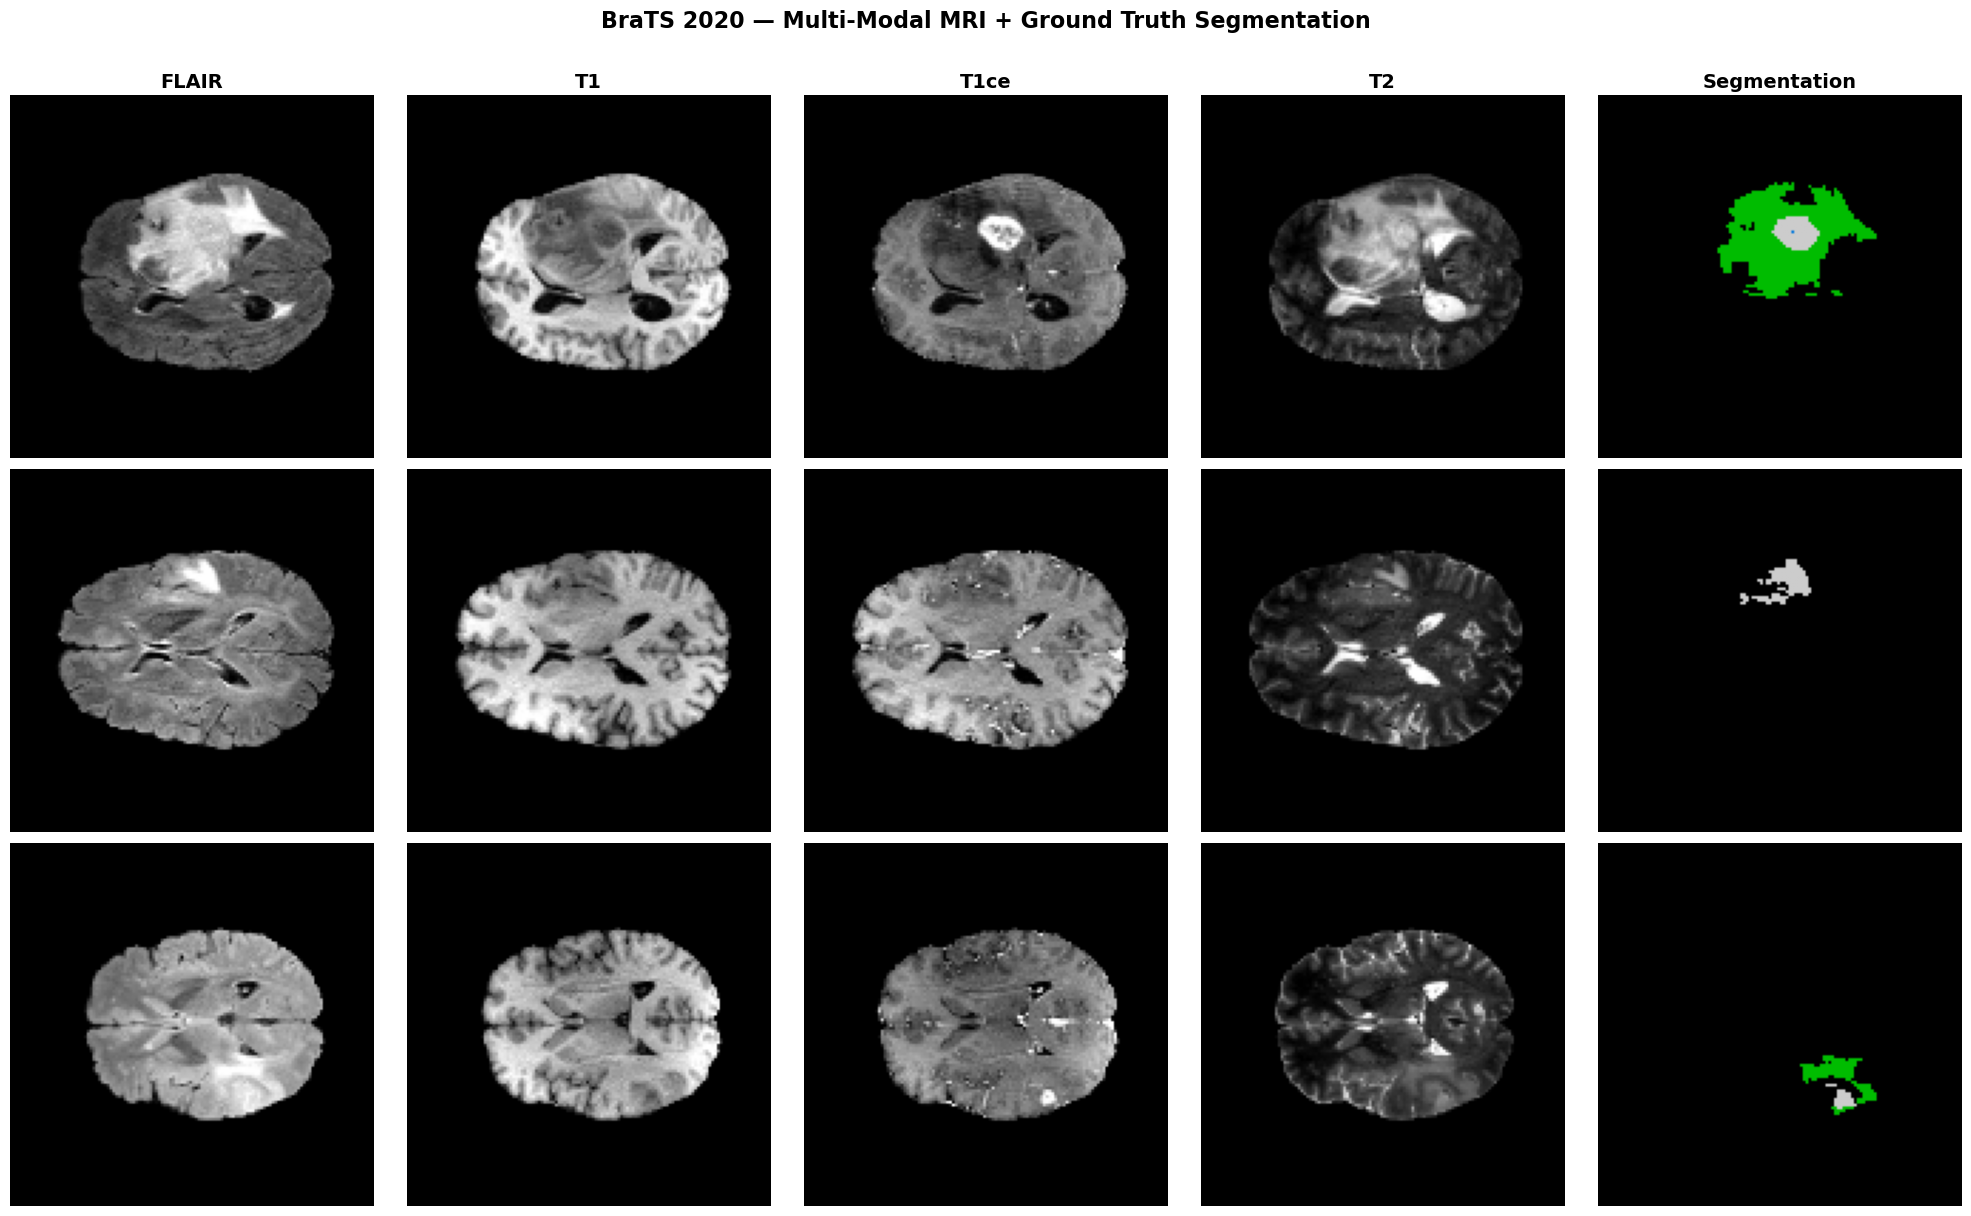

\nSegmentation Label Legend:
  0 = Background
  1 = Necrotic core / Non-enhancing tumor (NCR/NET)
  2 = Peritumoral edema (ED)
  4 = GD-enhancing tumor (ET)
  → Whole Tumor (WT) = union of 1+2+4


In [6]:
# ── Cell 5: Multi-modal loading ───────────────────────────────────────────────
## 3. Multi-Modal MRI Exploration

def load_patient_multimodal(patient_dir, slice_idx=77, img_size=128):
    #Load all 4 modalities + seg for one patient.
    loader_tmp = BraTS2020Loader(os.path.dirname(patient_dir),
                                  img_size=img_size,
                                  slice_idx=slice_idx)
    modalities = {}
    for mod in ('flair', 't1', 't1ce', 't2'):
        try:
            vol = loader_tmp._load_nii(patient_dir, mod)
            modalities[mod] = loader_tmp._preprocess_slice(vol[:, :, slice_idx])
        except Exception:
            modalities[mod] = np.zeros((img_size, img_size), dtype=np.float32)

    try:
        seg = loader_tmp._load_nii(patient_dir, 'seg')
        seg_sl = seg[:, :, slice_idx]
        modalities['seg'] = cv2.resize(seg_sl.astype(np.float32),
                                        (img_size, img_size),
                                        interpolation=cv2.INTER_NEAREST)
    except Exception:
        modalities['seg'] = np.zeros((img_size, img_size), dtype=np.float32)

    return modalities

# ── Visualise a tumor patient's 4 modalities ──────────────────────────────────
tumor_patient_dirs = [patient_dirs[i] for i, l in enumerate(y_labels) if l == 1]

if len(tumor_patient_dirs) >= 3:
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    modal_titles = ['FLAIR', 'T1', 'T1ce', 'T2', 'Segmentation']

    for row, pdir in enumerate(tumor_patient_dirs[:3]):
        mods = load_patient_multimodal(pdir, SLICE_IDX, IMG_SIZE)

        for col, (key, title) in enumerate(zip(
                ['flair','t1','t1ce','t2','seg'], modal_titles)):
            if key == 'seg':
                cmap = 'nipy_spectral'
            else:
                cmap = 'gray'
            axes[row, col].imshow(mods[key], cmap=cmap, vmin=0)
            if row == 0:
                axes[row, col].set_title(title, fontsize=14, fontweight='bold')
            axes[row, col].set_ylabel(os.path.basename(pdir)[:20], fontsize=8)
            axes[row, col].axis('off')

    plt.suptitle('BraTS 2020 — Multi-Modal MRI + Ground Truth Segmentation',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# ── Segmentation label distribution ──────────────────────────────────────────
print("\\nSegmentation Label Legend:")
print("  0 = Background")
print("  1 = Necrotic core / Non-enhancing tumor (NCR/NET)")
print("  2 = Peritumoral edema (ED)")
print("  4 = GD-enhancing tumor (ET)")
print("  → Whole Tumor (WT) = union of 1+2+4")

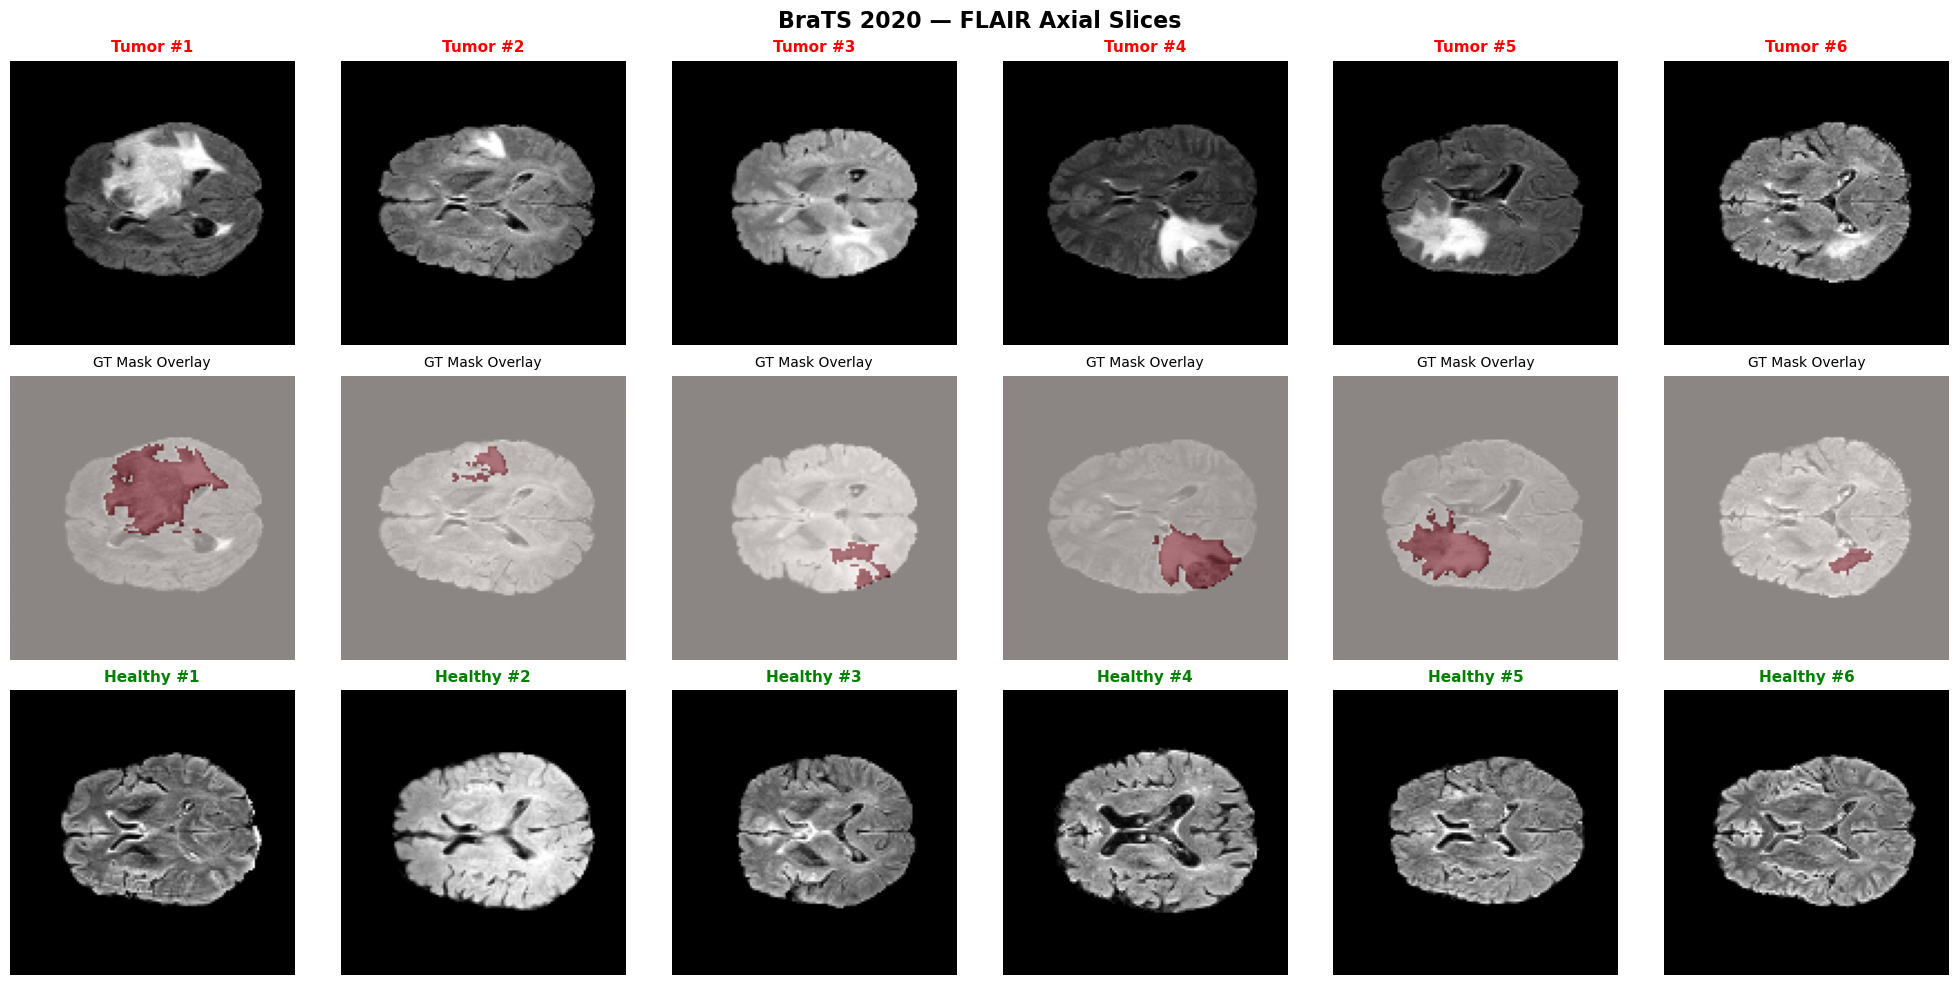

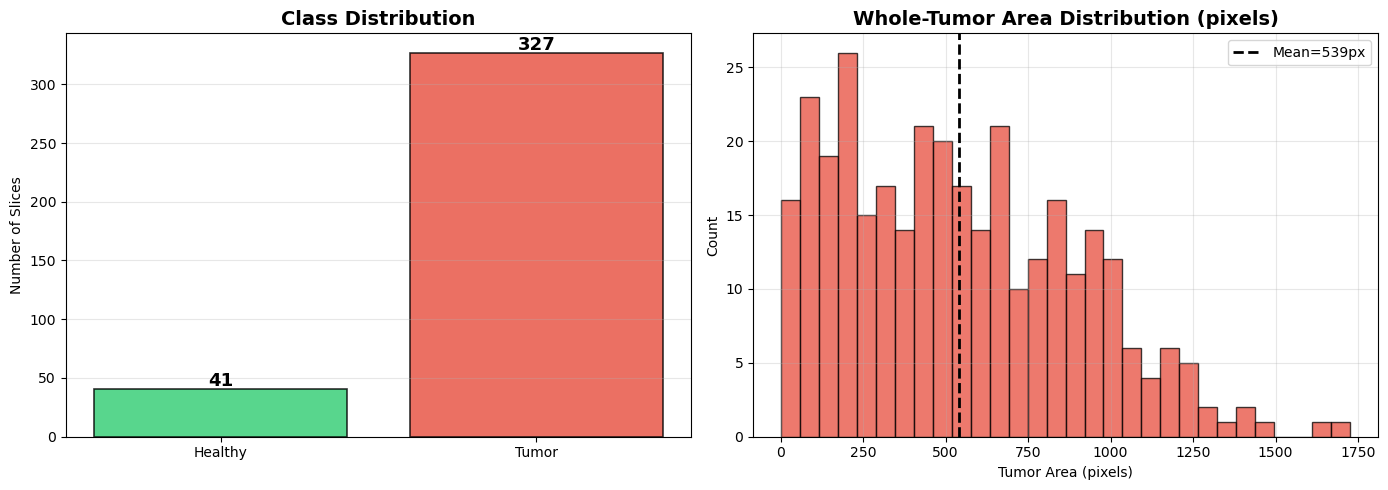

Tumor area stats (pixels):
  Mean   : 539.5
  Median : 489.0
  Std    : 354.9
  Min    : 2.0
  Max    : 1725.0


In [7]:
# ── Cell 6: EDA ───────────────────────────────────────────────────────────────
"## 4. Dataset Visualisation & EDA"

# ── Sample grid: tumor vs healthy ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(20, 10))

tumor_idx   = np.where(y_labels == 1)[0]
healthy_idx = np.where(y_labels == 0)[0]

for i in range(6):
    t_i = tumor_idx[i]
    h_i = healthy_idx[i] if i < len(healthy_idx) else tumor_idx[i+6]

    # Row 0: Tumor MRI
    axes[0, i].imshow(X_images[t_i], cmap='gray')
    axes[0, i].set_title(f'Tumor #{i+1}', fontsize=11, fontweight='bold', color='red')
    axes[0, i].axis('off')

    # Row 1: Ground-truth mask overlay
    axes[1, i].imshow(X_images[t_i], cmap='gray')
    axes[1, i].imshow(y_masks[t_i], cmap='Reds', alpha=0.55)
    axes[1, i].set_title('GT Mask Overlay', fontsize=10)
    axes[1, i].axis('off')

    # Row 2: Healthy
    axes[2, i].imshow(X_images[h_i], cmap='gray')
    axes[2, i].set_title(f'Healthy #{i+1}', fontsize=11, fontweight='bold', color='green')
    axes[2, i].axis('off')

plt.suptitle('BraTS 2020 — FLAIR Axial Slices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Class distribution ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
unique, counts = np.unique(y_labels, return_counts=True)
bars = axes[0].bar(['Healthy', 'Tumor'], counts,
                   color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.2)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Slices')
axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                 ha='center', fontweight='bold', fontsize=13)

# Tumor area distribution
tumor_areas = [y_masks[i].sum() for i in tumor_idx]
axes[1].hist(tumor_areas, bins=30, color='#e74c3c', alpha=0.75, edgecolor='black')
axes[1].set_title('Whole-Tumor Area Distribution (pixels)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tumor Area (pixels)')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(tumor_areas), color='black', linestyle='--',
                linewidth=2, label=f'Mean={np.mean(tumor_areas):.0f}px')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Tumor area stats (pixels):")
print(f"  Mean   : {np.mean(tumor_areas):.1f}")
print(f"  Median : {np.median(tumor_areas):.1f}")
print(f"  Std    : {np.std(tumor_areas):.1f}")
print(f"  Min    : {np.min(tumor_areas):.1f}")
print(f"  Max    : {np.max(tumor_areas):.1f}")


Dataset Split:
  Training   : 249 slices  (221 tumor / 28 healthy)
  Validation : 45 slices  (40 tumor / 5 healthy)
  Test       : 74 slices  (66 tumor / 8 healthy)
\nReshaped: (249, 128, 128, 1)  (N, H, W, C)


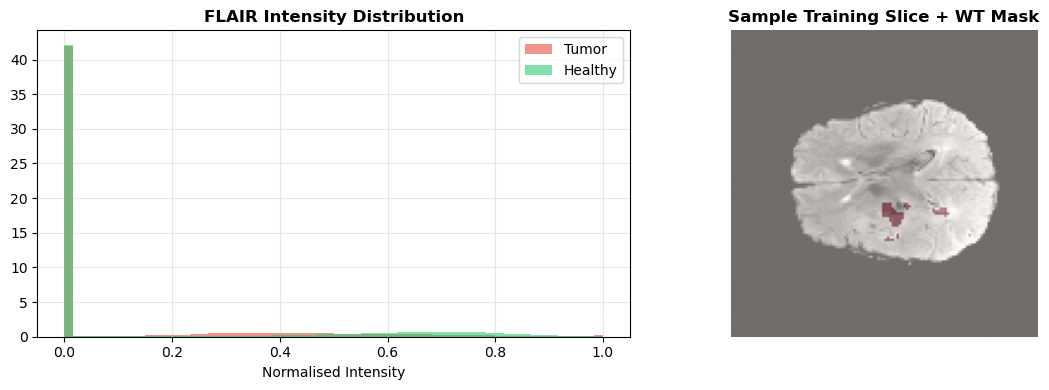

In [8]:
# ── Cell 7: Data split ────────────────────────────────────────────────────────
## 5. Data Preprocessing & Train/Val/Test Split"

# ── Patient-level stratified split (avoids data leakage) ─────────────────────
X_train, X_test, y_train_labels, y_test_labels, y_train_masks, y_test_masks = train_test_split(X_images, y_labels, y_masks, test_size=0.20, stratify=y_labels, random_state=42)

X_train, X_val, y_train_labels, y_val_labels, y_train_masks, y_val_masks = train_test_split(X_train, y_train_labels, y_train_masks,test_size=0.15, stratify=y_train_labels, random_state=42)

print("Dataset Split:")
print(f"  Training   : {X_train.shape[0]} slices  "
      f"({y_train_labels.sum()} tumor / {(y_train_labels==0).sum()} healthy)")
print(f"  Validation : {X_val.shape[0]} slices  "
      f"({y_val_labels.sum()} tumor / {(y_val_labels==0).sum()} healthy)")
print(f"  Test       : {X_test.shape[0]} slices  "
      f"({y_test_labels.sum()} tumor / {(y_test_labels==0).sum()} healthy)")

# ── Add channel dimension (CNN/U-Net expect (N, H, W, 1)) ─────────────────────
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

y_train_masks = y_train_masks[..., np.newaxis]
y_val_masks   = y_val_masks[..., np.newaxis]
y_test_masks  = y_test_masks[..., np.newaxis]

print(f"\\nReshaped: {X_train.shape}  (N, H, W, C)")

# ── Intensity distribution check ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train[y_train_labels==1].flatten(), bins=60,
             color='#e74c3c', alpha=0.6, label='Tumor', density=True)
axes[0].hist(X_train[y_train_labels==0].flatten(), bins=60,
             color='#2ecc71', alpha=0.6, label='Healthy', density=True)
axes[0].set_title('FLAIR Intensity Distribution', fontweight='bold')
axes[0].set_xlabel('Normalised Intensity')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].imshow(X_train[y_train_labels==1][0, :, :, 0], cmap='gray')
axes[1].imshow(y_train_masks[y_train_labels==1][0, :, :, 0],
               cmap='Reds', alpha=0.45)
axes[1].set_title('Sample Training Slice + WT Mask', fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [9]:
# ── Cell 8: CNN ───────────────────────────────────────────────────────────────
## 6. CNN Model for Tumor Classification"

def build_cnn_classifier(input_shape=(128, 128, 1)):
   #CNN binary classifier: Tumor (1) vs Healthy (0)

    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.30),

        # Dense head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


cnn_model = build_cnn_classifier(input_shape=(IMG_SIZE, IMG_SIZE, 1))

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 8,711,649 (33.23 MB)

 Trainable params: 8,709,985 (33.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [10]:
# ── Cell 9: Train CNN ─────────────────────────────────────────────────────────
## 7. Train CNN Classifier"))

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation (only on training data)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10,
    fill_mode='nearest'
)

cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_auc', patience=12, mode='max',
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                 min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_cnn_brats2020.h5', monitor='val_auc',
                               mode='max', save_best_only=True, verbose=1)
]

print("Training CNN Classifier on BraTS 2020...\\n")
history_cnn = cnn_model.fit(
    datagen.flow(X_train, y_train_labels, batch_size=32),
    validation_data=(X_val, y_val_labels),
    epochs=50,
    callbacks=cnn_callbacks,
    verbose=1
)

Training CNN Classifier on BraTS 2020...\n
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5436 - auc: 0.5714 - loss: 1.0207 - precision: 0.9170 - recall: 0.5302
Epoch 1: val_auc improved from None to 0.50000, saving model to best_cnn_brats2020.h5



Epoch 1: finished saving model to best_cnn_brats2020.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5502 - auc: 0.6092 - loss: 1.0233 - precision: 0.9225 - recall: 0.5385 - val_accuracy: 0.8889 - val_auc: 0.5000 - val_loss: 0.3973 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6347 - auc: 0.7736 - loss: 0.8220 - precision: 0.9504 - recall: 0.6264
Epoch 2: val_auc did not improve from 0.50000
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6466 - auc: 0.7560 - loss: 0.8130 - precision: 0.9404 - recall: 0.6425 - val_accuracy: 0.8889 - val_auc: 0.5000 - val_loss: 0.3642 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6321 - auc: 0.7392 - loss: 0.7632 - precision: 0.9355 - recall: 0.6237
Epoch 3: val_auc did not improve from 0.50000
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6466 - auc: 0.7367 - loss: 0.7764 

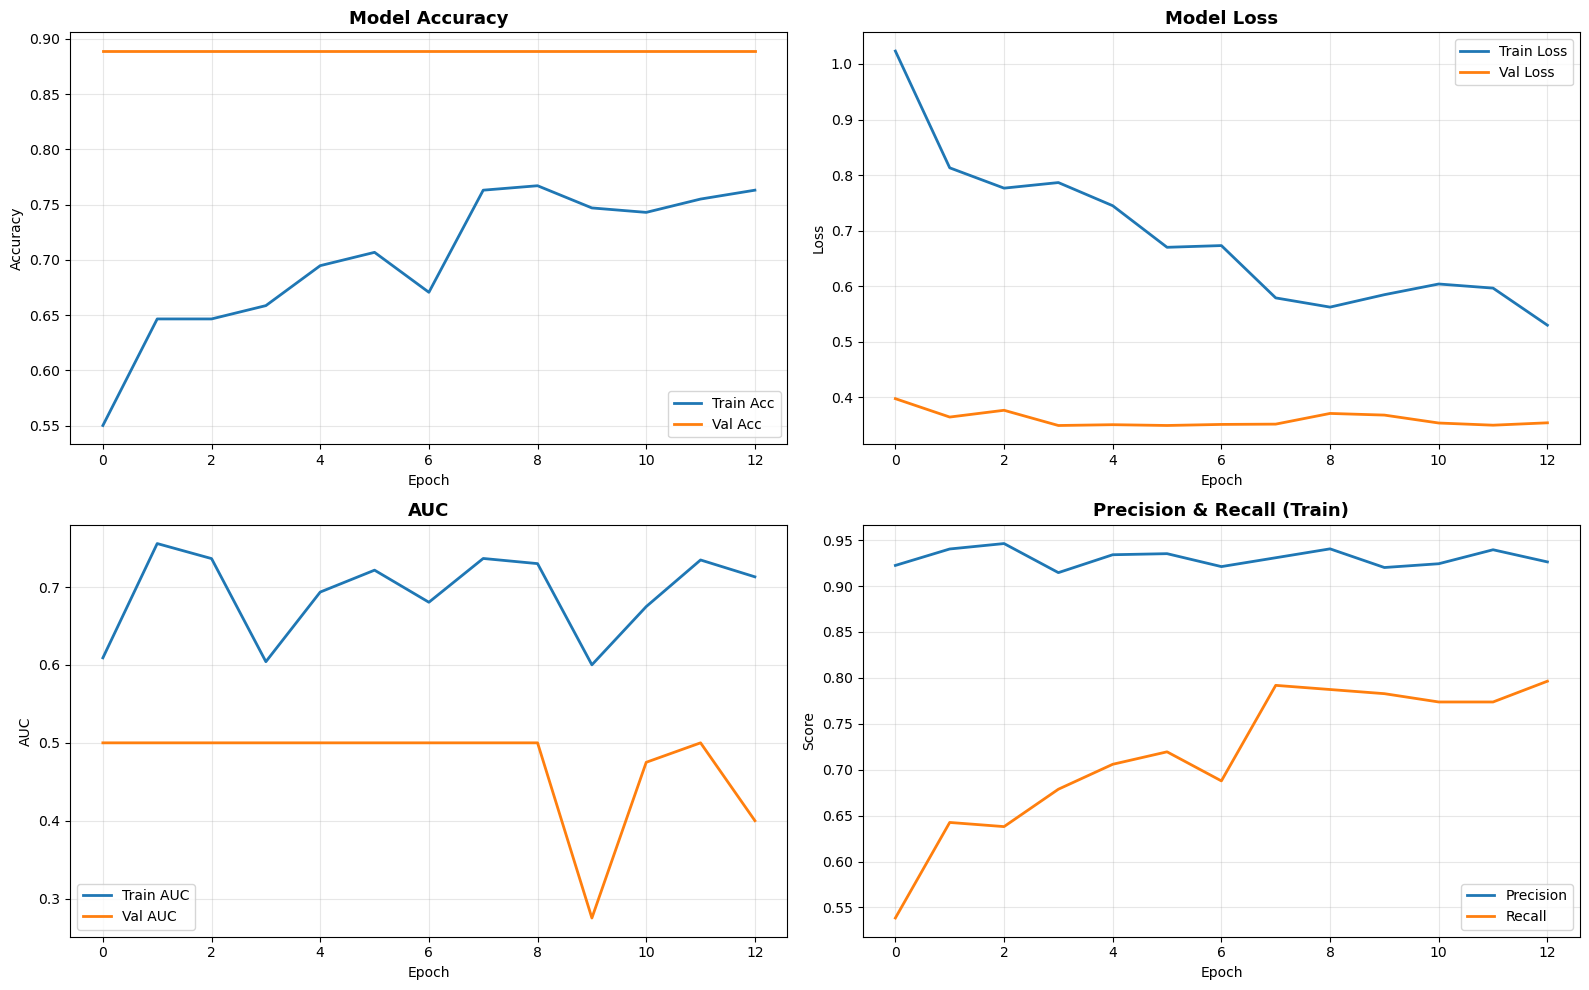

\n============================================================
CNN CLASSIFICATION REPORT — BraTS 2020 Test Set
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00         8
       Tumor       0.89      1.00      0.94        66

    accuracy                           0.89        74
   macro avg       0.45      0.50      0.47        74
weighted avg       0.80      0.89      0.84        74



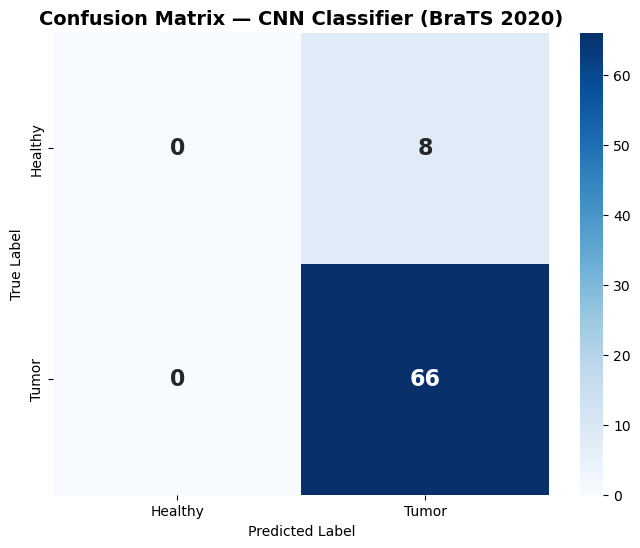

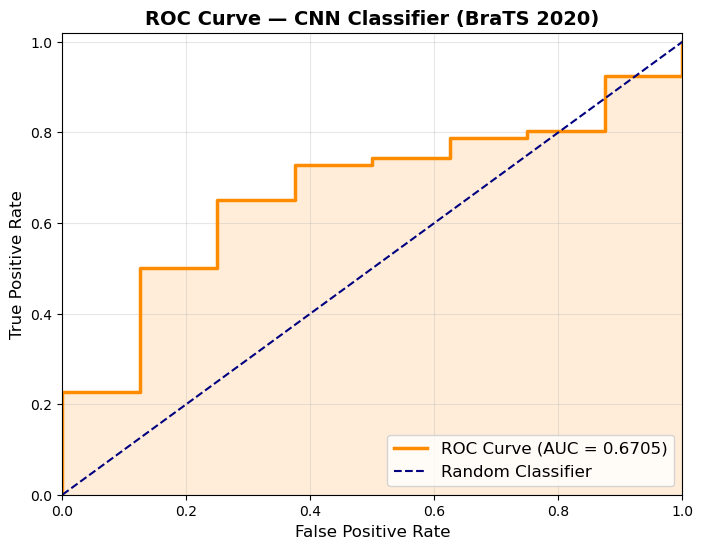

In [11]:
# ── Cell 10: CNN Eval ─────────────────────────────────────────────────────────
## 8. CNN Performance Evaluation
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(history_cnn.history['accuracy'],     label='Train Acc', linewidth=2)
axes[0,0].plot(history_cnn.history['val_accuracy'], label='Val Acc',   linewidth=2)
axes[0,0].set_title('Model Accuracy', fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history_cnn.history['loss'],     label='Train Loss', linewidth=2)
axes[0,1].plot(history_cnn.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0,1].set_title('Model Loss', fontweight='bold', fontsize=13)
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(history_cnn.history['auc'],     label='Train AUC', linewidth=2)
axes[1,0].plot(history_cnn.history['val_auc'], label='Val AUC',   linewidth=2)
axes[1,0].set_title('AUC', fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('AUC')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history_cnn.history['precision'], label='Precision', linewidth=2)
axes[1,1].plot(history_cnn.history['recall'],    label='Recall',    linewidth=2)
axes[1,1].set_title('Precision & Recall (Train)', fontweight='bold', fontsize=13)
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Score')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Test-set evaluation ───────────────────────────────────────────────────────
y_pred_proba = cnn_model.predict(X_test, verbose=0)
y_pred       = (y_pred_proba > 0.5).astype(int).flatten()

print("\\n" + "="*60)
print("CNN CLASSIFICATION REPORT — BraTS 2020 Test Set")
print("="*60)
print(classification_report(y_test_labels, y_pred,
                             target_names=['Healthy', 'Tumor']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Tumor'],
            yticklabels=['Healthy', 'Tumor'],
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Confusion Matrix — CNN Classifier (BraTS 2020)',
          fontweight='bold', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.show()

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_labels, y_pred_proba)
auc_score   = roc_auc_score(y_test_labels, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], 'navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.15, color='darkorange')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — CNN Classifier (BraTS 2020)',
          fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [12]:
# ── Cell 11: U-Net ───────────────────────────────────────────────────────────
## 9. U-Net Model for Whole-Tumor Segmentation"

def build_unet(input_shape=(128, 128, 1)):
    #U-Net encoder-decoder for binary Whole-Tumor segmentation.

    inputs = layers.Input(input_shape)

    # ── Encoder ───────────────────────────────────────────────────────────────
    c1 = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)
    p1 = layers.Dropout(0.10)(p1)

    c2 = layers.Conv2D(64,  (3,3), activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(64,  (3,3), activation='relu', padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)
    p2 = layers.Dropout(0.20)(p2)

    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)
    p3 = layers.Dropout(0.20)(p3)

    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c4)
    c4 = layers.BatchNormalization()(c4)
    p4 = layers.MaxPooling2D((2,2))(c4)
    p4 = layers.Dropout(0.30)(p4)

    # ── Bottleneck ────────────────────────────────────────────────────────────
    c5 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(p4)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c5)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Dropout(0.30)(c5)

    # ── Decoder ───────────────────────────────────────────────────────────────
    u6 = layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Dropout(0.20)(c6)

    u7 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Dropout(0.20)(c7)

    u8 = layers.Conv2DTranspose(64,  (2,2), strides=(2,2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(64,  (3,3), activation='relu', padding='same')(u8)
    c8 = layers.BatchNormalization()(c8)
    c8 = layers.Conv2D(64,  (3,3), activation='relu', padding='same')(c8)
    c8 = layers.BatchNormalization()(c8)
    c8 = layers.Dropout(0.10)(c8)

    u9 = layers.Conv2DTranspose(32,  (2,2), strides=(2,2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(u9)
    c9 = layers.BatchNormalization()(c9)
    c9 = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(c9)
    c9 = layers.BatchNormalization()(c9)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c9)

    return models.Model(inputs=[inputs], outputs=[outputs])


# ── Loss & metric functions ───────────────────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(y_pred)
    inter    = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce  = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred > 0.5, tf.float32))
    inter    = tf.keras.backend.sum(y_true_f * y_pred_f)
    union    = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - inter
    return (inter + smooth) / (union + smooth)


# ── Build & compile U-Net ─────────────────────────────────────────────────────
unet_model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1))

unet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric, 'binary_accuracy']
)

print("U-Net Model Summary:")
unet_model.summary()


U-Net Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 128, 128, 32)      │             320 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_8         │ (None, 128, 128, 32)      │             128 │ conv2d_6[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 128, 128, 32)      │           9,248 │ batch_normalization_8[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_9         │ (None, 128, 128, 32)      │             128 │ conv2d_7[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 64, 64, 32)        │               0 │ batch_normalization_9[0][… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_5 (Dropout)           │ (None, 64, 64, 32)        │               0 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 64, 64, 64)        │          18,496 │ dropout_5[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_10        │ (None, 64, 64, 64)        │             256 │ conv2d_8[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 64, 64, 64)        │          36,928 │ batch_normalization_10[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_11        │ (None, 64, 64, 64)        │             256 │ conv2d_9[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 32, 32, 64)        │               0 │ batch_normalization_11[0]… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 32, 32, 64)        │               0 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 32, 32, 128)       │          73,856 │ dropout_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 7,771,297 (29.65 MB)

 Trainable params: 7,765,409 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [13]:
# ── Cell 12: Train U-Net ──────────────────────────────────────────────────────
## 10. Train U-Net Segmentation Model"))

unet_callbacks = [
    callbacks.EarlyStopping(monitor='val_dice_coefficient', patience=20, mode='max',
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                                 min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_unet_brats2020.h5',
                               monitor='val_dice_coefficient', mode='max',
                               save_best_only=True, verbose=1)
]

# Class weight to handle foreground/background imbalance
pos_pixels = y_train_masks.sum()
neg_pixels = y_train_masks.size - pos_pixels
class_weight = {0: 1.0, 1: neg_pixels / (pos_pixels + 1e-6)}
print(f"Class weights → background: 1.0 | tumor: {class_weight[1]:.2f}")

print("\\nTraining U-Net on BraTS 2020 Whole-Tumor masks...\\n")
history_unet = unet_model.fit(
    X_train, y_train_masks,
    validation_data=(X_val, y_val_masks),
    epochs=60,
    batch_size=16,
    callbacks=unet_callbacks,
    verbose=1
)

Class weights → background: 1.0 | tumor: 33.33
\nTraining U-Net on BraTS 2020 Whole-Tumor masks...\n
Epoch 1/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - binary_accuracy: 0.5994 - dice_coefficient: 0.0755 - iou_metric: 0.0625 - loss: 1.7040
Epoch 1: val_dice_coefficient improved from None to 0.06439, saving model to best_unet_brats2020.h5



Epoch 1: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - binary_accuracy: 0.7089 - dice_coefficient: 0.0938 - iou_metric: 0.1033 - loss: 1.5986 - val_binary_accuracy: 0.8579 - val_dice_coefficient: 0.0644 - val_iou_metric: 0.1613 - val_loss: 1.5529 - learning_rate: 0.0010
Epoch 2/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - binary_accuracy: 0.9168 - dice_coefficient: 0.1173 - iou_metric: 0.2522 - loss: 1.4207
Epoch 2: val_dice_coefficient improved from 0.06439 to 0.06651, saving model to best_unet_brats2020.h5



Epoch 2: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - binary_accuracy: 0.9307 - dice_coefficient: 0.1264 - iou_metric: 0.3033 - loss: 1.3817 - val_binary_accuracy: 0.1663 - val_dice_coefficient: 0.0665 - val_iou_metric: 0.0322 - val_loss: 3.1587 - learning_rate: 0.0010
Epoch 3/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9646 - dice_coefficient: 0.1329 - iou_metric: 0.4483 - loss: 1.3032
Epoch 3: val_dice_coefficient did not improve from 0.06651
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - binary_accuracy: 0.9649 - dice_coefficient: 0.1433 - iou_metric: 0.4570 - loss: 1.2769 - val_binary_accuracy: 0.0312 - val_dice_coefficient: 0.0542 - val_iou_metric: 0.0279 - val_loss: 95.6735 - learning_rate: 0.0010
Epoch 4/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9801 - dice_coefficient: 0.1528 - iou_metric: 0.5490 - loss: 1.2111
Epoch 4: val_dice_coefficient did not improve from 0.06651
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s


Epoch 11: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - binary_accuracy: 0.9901 - dice_coefficient: 0.3941 - iou_metric: 0.7159 - loss: 0.7236 - val_binary_accuracy: 0.2693 - val_dice_coefficient: 0.0699 - val_iou_metric: 0.0366 - val_loss: 17.7782 - learning_rate: 5.0000e-04
Epoch 12/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - binary_accuracy: 0.9902 - dice_coefficient: 0.4138 - iou_metric: 0.7169 - loss: 0.7009
Epoch 12: val_dice_coefficient did not improve from 0.06989
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - binary_accuracy: 0.9903 - dice_coefficient: 0.4267 - iou_metric: 0.7241 - loss: 0.6834 - val_binary_accuracy: 0.1417 - val_dice_coefficient: 0.0604 - val_iou_metric: 0.0313 - val_loss: 38.3646 - learning_rate: 5.0000e-04
Epoch 13/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - binary_accuracy: 0.9908 - dice_coefficient: 0.4453 - iou_metric: 0.7273 - loss: 0.6564
Epoch 13: val_dice_coefficient improved from 0.06989 to 0.08682, saving model t


Epoch 13: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - binary_accuracy: 0.9905 - dice_coefficient: 0.4587 - iou_metric: 0.7274 - loss: 0.6422 - val_binary_accuracy: 0.4267 - val_dice_coefficient: 0.0868 - val_iou_metric: 0.0462 - val_loss: 12.7852 - learning_rate: 5.0000e-04
Epoch 14/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9916 - dice_coefficient: 0.4851 - iou_metric: 0.7447 - loss: 0.6066
Epoch 14: val_dice_coefficient did not improve from 0.08682
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - binary_accuracy: 0.9914 - dice_coefficient: 0.5002 - iou_metric: 0.7472 - loss: 0.5892 - val_binary_accuracy: 0.2963 - val_dice_coefficient: 0.0726 - val_iou_metric: 0.0380 - val_loss: 18.3460 - learning_rate: 5.0000e-04
Epoch 15/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9922 - dice_coefficient: 0.5264 - iou_metric: 0.7621 - loss: 0.5531
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

E

...


Epoch 53: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - binary_accuracy: 0.9959 - dice_coefficient: 0.8603 - iou_metric: 0.8700 - loss: 0.1660 - val_binary_accuracy: 0.9914 - val_dice_coefficient: 0.7864 - val_iou_metric: 0.7264 - val_loss: 0.2809 - learning_rate: 1.2500e-04
Epoch 54/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9961 - dice_coefficient: 0.8606 - iou_metric: 0.8719 - loss: 0.1642
Epoch 54: val_dice_coefficient did not improve from 0.78638
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - binary_accuracy: 0.9960 - dice_coefficient: 0.8628 - iou_metric: 0.8719 - loss: 0.1629 - val_binary_accuracy: 0.9903 - val_dice_coefficient: 0.7760 - val_iou_metric: 0.7042 - val_loss: 0.3074 - learning_rate: 1.2500e-04
Epoch 55/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9962 - dice_coefficient: 0.8641 - iou_metric: 0.8744 - loss: 0.1599
Epoch 55: val_dice_coefficient improved from 0.78638 to 0.78718, saving model to 


Epoch 55: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - binary_accuracy: 0.9961 - dice_coefficient: 0.8665 - iou_metric: 0.8754 - loss: 0.1582 - val_binary_accuracy: 0.9910 - val_dice_coefficient: 0.7872 - val_iou_metric: 0.7211 - val_loss: 0.2922 - learning_rate: 1.2500e-04
Epoch 56/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9961 - dice_coefficient: 0.8640 - iou_metric: 0.8701 - loss: 0.1610
Epoch 56: val_dice_coefficient improved from 0.78718 to 0.78889, saving model to best_unet_brats2020.h5



Epoch 56: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - binary_accuracy: 0.9959 - dice_coefficient: 0.8650 - iou_metric: 0.8694 - loss: 0.1603 - val_binary_accuracy: 0.9910 - val_dice_coefficient: 0.7889 - val_iou_metric: 0.7219 - val_loss: 0.2914 - learning_rate: 1.2500e-04
Epoch 57/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9960 - dice_coefficient: 0.8664 - iou_metric: 0.8696 - loss: 0.1598
Epoch 57: val_dice_coefficient improved from 0.78889 to 0.78911, saving model to best_unet_brats2020.h5



Epoch 57: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - binary_accuracy: 0.9959 - dice_coefficient: 0.8663 - iou_metric: 0.8669 - loss: 0.1606 - val_binary_accuracy: 0.9912 - val_dice_coefficient: 0.7891 - val_iou_metric: 0.7225 - val_loss: 0.2836 - learning_rate: 1.2500e-04
Epoch 58/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9961 - dice_coefficient: 0.8673 - iou_metric: 0.8714 - loss: 0.1571
Epoch 58: val_dice_coefficient did not improve from 0.78911
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - binary_accuracy: 0.9960 - dice_coefficient: 0.8689 - iou_metric: 0.8706 - loss: 0.1568 - val_binary_accuracy: 0.9908 - val_dice_coefficient: 0.7848 - val_iou_metric: 0.7141 - val_loss: 0.2907 - learning_rate: 1.2500e-04
Epoch 59/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9962 - dice_coefficient: 0.8707 - iou_metric: 0.8742 - loss: 0.1532
Epoch 59: val_dice_coefficient improved from 0.78911 to 0.79470, saving model to 


Epoch 59: finished saving model to best_unet_brats2020.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - binary_accuracy: 0.9961 - dice_coefficient: 0.8725 - iou_metric: 0.8738 - loss: 0.1523 - val_binary_accuracy: 0.9910 - val_dice_coefficient: 0.7947 - val_iou_metric: 0.7249 - val_loss: 0.2887 - learning_rate: 1.2500e-04
Epoch 60/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9961 - dice_coefficient: 0.8698 - iou_metric: 0.8718 - loss: 0.1536
Epoch 60: val_dice_coefficient did not improve from 0.79470
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - binary_accuracy: 0.9961 - dice_coefficient: 0.8738 - iou_metric: 0.8748 - loss: 0.1506 - val_binary_accuracy: 0.9913 - val_dice_coefficient: 0.7935 - val_iou_metric: 0.7245 - val_loss: 0.2756 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 59.


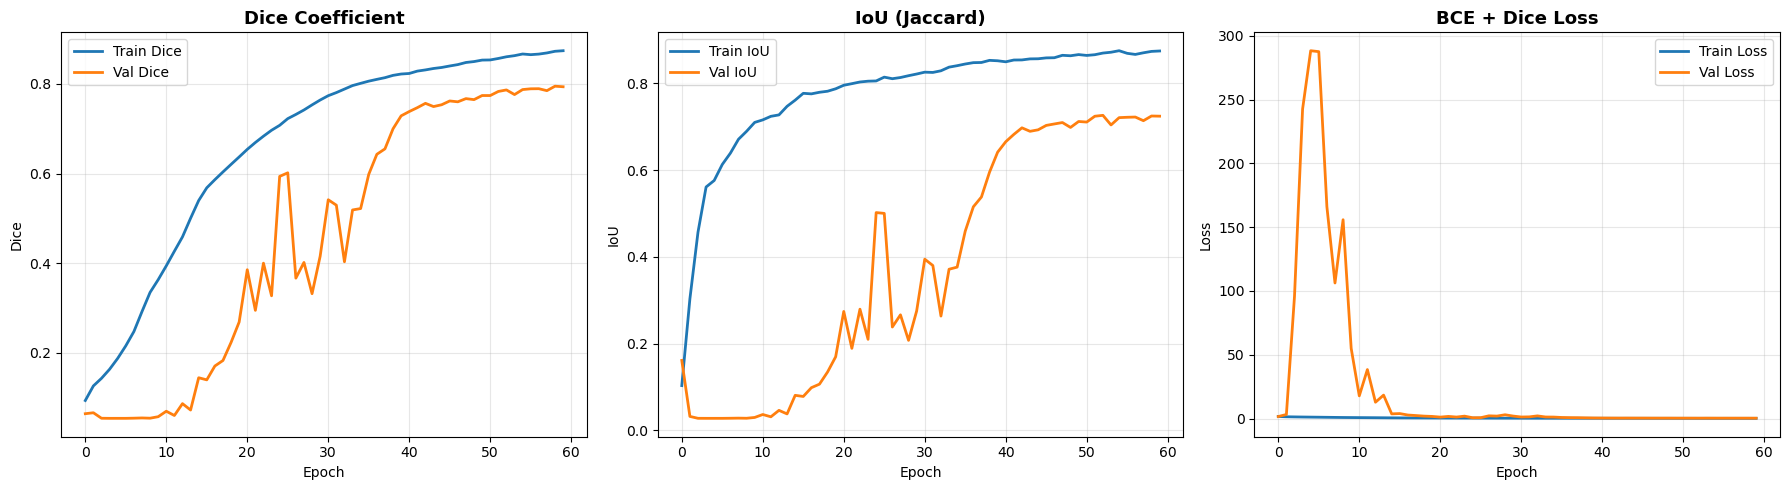

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 565ms/step
\n============================================================
U-NET TEST SET RESULTS — BraTS 2020
  Dice Coefficient : 0.8728
  IoU (Jaccard)    : 0.7744
  Per-sample Dice → mean=0.7804  std=0.2749  min=0.0000  max=1.0000


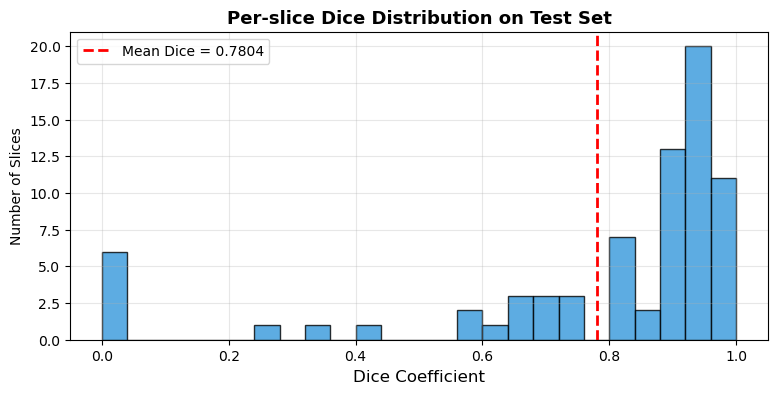

In [14]:
# ── Cell 13: U-Net Eval ───────────────────────────────────────────────────────
## 11. U-Net Performance Evaluation

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_unet.history['dice_coefficient'],     label='Train Dice', lw=2)
axes[0].plot(history_unet.history['val_dice_coefficient'], label='Val Dice',   lw=2)
axes[0].set_title('Dice Coefficient', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Dice')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_unet.history['iou_metric'],     label='Train IoU', lw=2)
axes[1].plot(history_unet.history['val_iou_metric'], label='Val IoU',   lw=2)
axes[1].set_title('IoU (Jaccard)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history_unet.history['loss'],     label='Train Loss', lw=2)
axes[2].plot(history_unet.history['val_loss'], label='Val Loss',   lw=2)
axes[2].set_title('BCE + Dice Loss', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Test-set inference ─────────────────────────────────────────────────────────
y_pred_masks        = unet_model.predict(X_test, verbose=1)
y_pred_masks_binary = (y_pred_masks > 0.5).astype(np.float32)

# Dice & IoU on test set
test_dice = dice_coefficient(y_test_masks, y_pred_masks_binary).numpy()
test_iou  = iou_metric(y_test_masks, y_pred_masks_binary).numpy()

print(f"\\n{'='*60}")
print(f"U-NET TEST SET RESULTS — BraTS 2020")
print(f"{'='*60}")
print(f"  Dice Coefficient : {test_dice:.4f}")
print(f"  IoU (Jaccard)    : {test_iou:.4f}")

# Per-sample stats
sample_dices = []
for i in range(len(X_test)):
    d = dice_coefficient(y_test_masks[i:i+1], y_pred_masks_binary[i:i+1]).numpy()
    sample_dices.append(d)

print(f"  Per-sample Dice → mean={np.mean(sample_dices):.4f}  "
      f"std={np.std(sample_dices):.4f}  "
      f"min={np.min(sample_dices):.4f}  "
      f"max={np.max(sample_dices):.4f}")

# Dice histogram
plt.figure(figsize=(9, 4))
plt.hist(sample_dices, bins=25, color='#3498db', edgecolor='black', alpha=0.8)
plt.axvline(np.mean(sample_dices), color='red', linestyle='--', lw=2,
            label=f'Mean Dice = {np.mean(sample_dices):.4f}')
plt.xlabel('Dice Coefficient', fontsize=12)
plt.ylabel('Number of Slices')
plt.title('Per-slice Dice Distribution on Test Set', fontweight='bold', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.show()

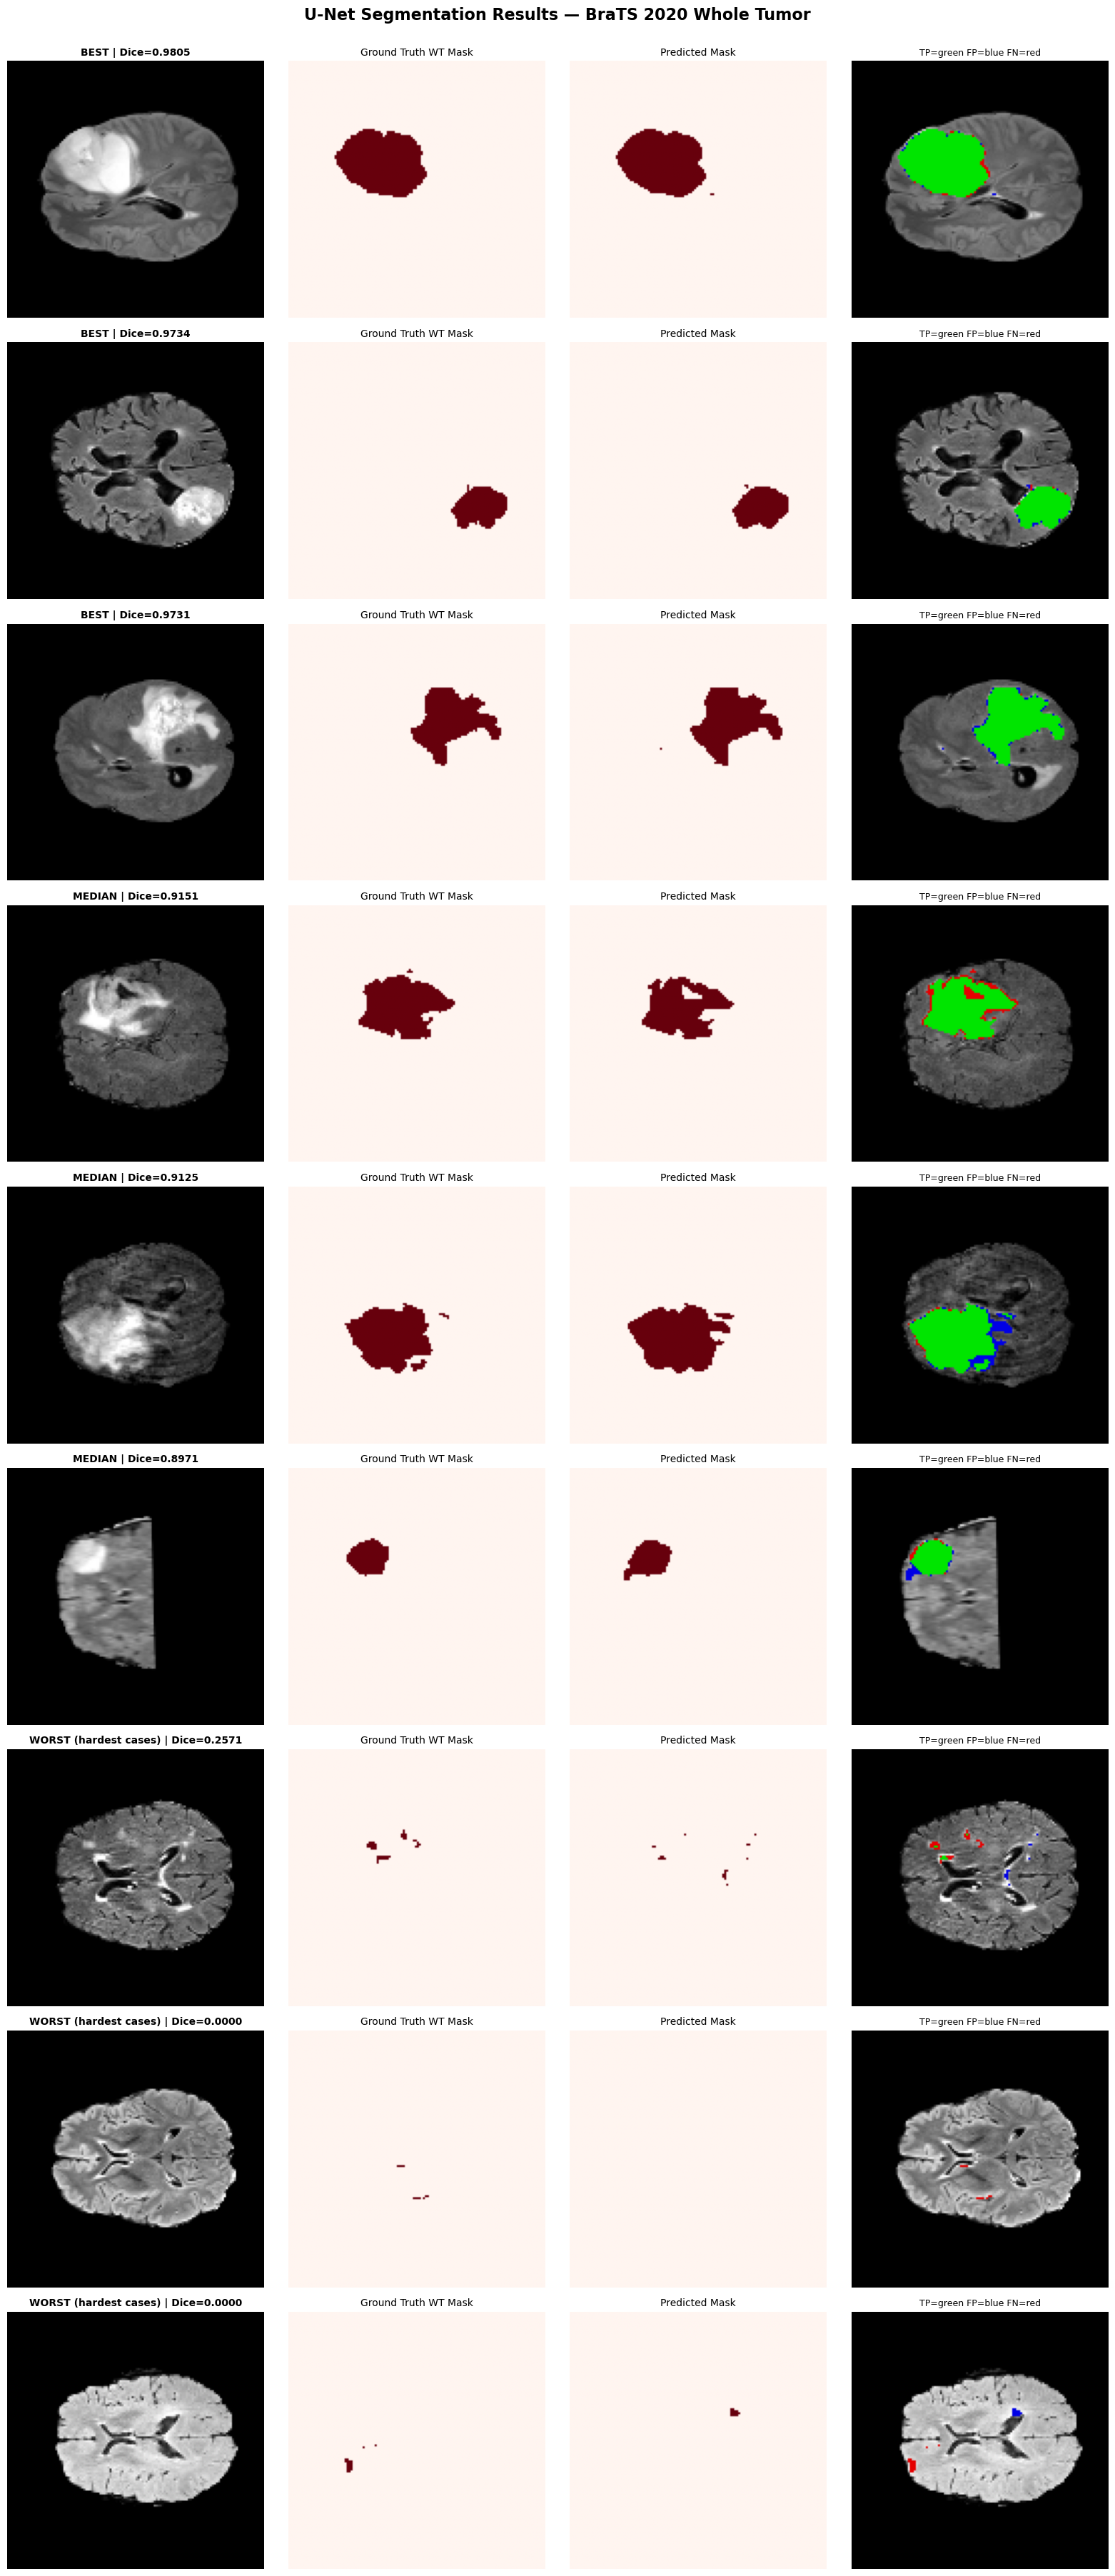

In [15]:

# ── Cell 14: Segmentation visualisation ──────────────────────────────────────
## 12. Segmentation Results Visualisation

# ── Show best and worst predictions ───────────────────────────────────────────
tumor_test_idx = np.where(y_test_labels == 1)[0]
sorted_by_dice = sorted(tumor_test_idx,
                         key=lambda i: sample_dices[i], reverse=True)

best_cases  = sorted_by_dice[:3]
worst_cases = sorted_by_dice[-3:]
mid_cases   = sorted_by_dice[len(sorted_by_dice)//2-1 : len(sorted_by_dice)//2+2]

fig, axes = plt.subplots(9, 4, figsize=(16, 36))
row = 0

for group_name, indices in [('BEST', best_cases),
                              ('MEDIAN', mid_cases),
                              ('WORST (hardest cases)', worst_cases)]:
    for idx in indices:
        axes[row, 0].imshow(X_test[idx, :, :, 0], cmap='gray')
        axes[row, 0].set_title(f'{group_name} | Dice={sample_dices[idx]:.4f}',
                                fontsize=10, fontweight='bold')
        axes[row, 0].set_ylabel('MRI Input'); axes[row, 0].axis('off')

        axes[row, 1].imshow(y_test_masks[idx, :, :, 0], cmap='Reds')
        axes[row, 1].set_title('Ground Truth WT Mask', fontsize=10)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(y_pred_masks_binary[idx, :, :, 0], cmap='Reds')
        axes[row, 2].set_title('Predicted Mask', fontsize=10)
        axes[row, 2].axis('off')

        # Overlay with error map
        overlay = np.stack([X_test[idx, :, :, 0]]*3, axis=-1)
        gt   = y_test_masks[idx, :, :, 0]
        pred = y_pred_masks_binary[idx, :, :, 0]
        tp_mask = (gt > 0) & (pred > 0)   # TP = green
        fp_mask = (gt == 0) & (pred > 0)  # FP = blue
        fn_mask = (gt > 0) & (pred == 0)  # FN = red
        overlay[tp_mask] = [0, 0.9, 0]
        overlay[fp_mask] = [0, 0, 0.9]
        overlay[fn_mask] = [0.9, 0, 0]
        axes[row, 3].imshow(np.clip(overlay, 0, 1))
        axes[row, 3].set_title('TP=green FP=blue FN=red', fontsize=9)
        axes[row, 3].axis('off')

        row += 1

plt.suptitle('U-Net Segmentation Results — BraTS 2020 Whole Tumor',
             fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()


\n================================================================================
TUMOR ANALYSIS REPORT — BraTS 2020
\nSample 1  (test idx=0, Dice=0.9268):
  Area                : 896.00 mm²
  Estimated Volume    : 896.00 mm³
  Equivalent Diameter : 33.78 mm
  Circularity Index   : 0.467
  Size Classification : Medium
  Risk Level          : Moderate Risk
\nSample 2  (test idx=2, Dice=0.6897):
  Area                : 147.00 mm²
  Estimated Volume    : 147.00 mm³
  Equivalent Diameter : 13.68 mm
  Circularity Index   : 0.296
  Size Classification : Micro
  Risk Level          : Minimal Risk
\nSample 3  (test idx=3, Dice=0.9187):
  Area                : 656.00 mm²
  Estimated Volume    : 656.00 mm³
  Equivalent Diameter : 28.90 mm
  Circularity Index   : 0.273
  Size Classification : Medium
  Risk Level          : Moderate Risk
\nSample 4  (test idx=4, Dice=0.6904):
  Area                : 540.00 mm²
  Estimated Volume    : 540.00 mm³
  Equivalent Diameter : 26.22 mm
  Circularity Index

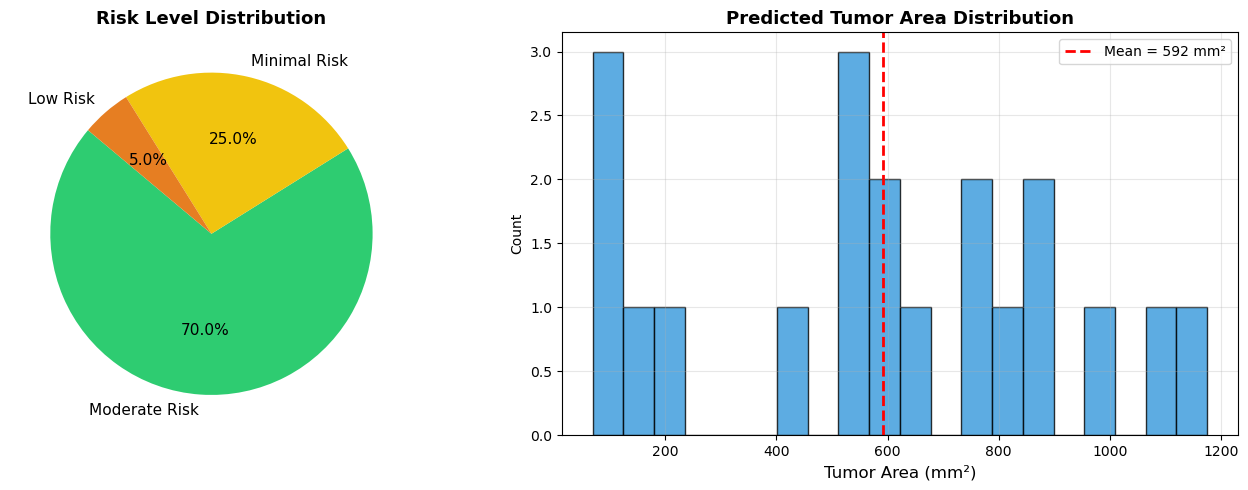

In [16]:
# ── Cell 15: Tumor Analyzer ───────────────────────────────────────────────────
## 13. Tumor Area Estimation & Severity Analysis"))

class TumorAnalyzer:
    
    #Quantitative analysis of the predicted tumor segmentation mask.
    #BraTS 2020 voxel spacing is approximately 1 mm³ isotropic.
    

    def __init__(self, pixel_spacing_mm=1.0, slice_thickness_mm=1.0):
        self.ps  = pixel_spacing_mm
        self.st  = slice_thickness_mm

    def calculate_tumor_area(self, mask):
        return float(np.sum(mask > 0)) * (self.ps ** 2)   # mm²

    def calculate_volume_estimate(self, mask):
        return self.calculate_tumor_area(mask) * self.st   # mm³

    def assess_severity(self, area_mm2):
        if   area_mm2 <  200: return "Micro",       "Minimal Risk"
        elif area_mm2 <  500: return "Small",        "Low Risk"
        elif area_mm2 < 1200: return "Medium",       "Moderate Risk"
        elif area_mm2 < 2500: return "Large",        "High Risk"
        else:                 return "Very Large",   "Critical Risk"

    def get_tumor_characteristics(self, mask):
        if np.sum(mask) == 0:
            return None

        area   = self.calculate_tumor_area(mask)
        volume = self.calculate_volume_estimate(mask)

        mask_u8    = (mask * 255).astype(np.uint8)
        contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            lc          = max(contours, key=cv2.contourArea)
            perimeter   = cv2.arcLength(lc, True) * self.ps
            circularity = (4 * np.pi * area / (perimeter ** 2)) if perimeter > 0 else 0
            x, y, w, h  = cv2.boundingRect(lc)
            equiv_diam  = np.sqrt(4 * area / np.pi)
        else:
            perimeter = circularity = equiv_diam = 0
            x = y = w = h = 0

        size_cls, risk = self.assess_severity(area)

        return {
            'area_mm2':              area,
            'volume_mm3':            volume,
            'perimeter_mm':          perimeter,
            'circularity':           circularity,
            'equivalent_diameter_mm': equiv_diam,
            'bounding_box':          (x, y, w, h),
            'size_classification':   size_cls,
            'risk_level':            risk,
        }


analyzer = TumorAnalyzer(pixel_spacing_mm=1.0, slice_thickness_mm=1.0)

# ── Batch analysis ─────────────────────────────────────────────────────────────
tumor_stats = []
for i in tumor_test_idx[:20]:
    ch = analyzer.get_tumor_characteristics(y_pred_masks_binary[i, :, :, 0])
    if ch:
        ch['sample_idx'] = i
        ch['dice']       = sample_dices[i]
        tumor_stats.append(ch)

print("\\n" + "="*80)
print("TUMOR ANALYSIS REPORT — BraTS 2020")
print("="*80)
for j, s in enumerate(tumor_stats[:6]):
    print(f"\\nSample {j+1}  (test idx={s['sample_idx']}, Dice={s['dice']:.4f}):")
    print(f"  Area                : {s['area_mm2']:.2f} mm²")
    print(f"  Estimated Volume    : {s['volume_mm3']:.2f} mm³")
    print(f"  Equivalent Diameter : {s['equivalent_diameter_mm']:.2f} mm")
    print(f"  Circularity Index   : {s['circularity']:.3f}")
    print(f"  Size Classification : {s['size_classification']}")
    print(f"  Risk Level          : {s['risk_level']}")

# ── Summary stats ──────────────────────────────────────────────────────────────
if tumor_stats:
    areas = [s['area_mm2'] for s in tumor_stats]
    risk_counts = {}
    for s in tumor_stats:
        risk_counts[s['risk_level']] = risk_counts.get(s['risk_level'], 0) + 1

    print("\\n" + "="*80)
    print("COHORT SUMMARY")
    print("="*80)
    print(f"  Tumors analysed : {len(tumor_stats)}")
    print(f"  Mean area       : {np.mean(areas):.1f} mm²")
    print(f"  Median area     : {np.median(areas):.1f} mm²")
    print(f"  Area range      : {np.min(areas):.1f} – {np.max(areas):.1f} mm²")
    print(f"\\n  Risk distribution:")
    for risk, cnt in sorted(risk_counts.items()):
        print(f"    {risk:<18}: {cnt}")

# ── Risk distribution pie chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if risk_counts:
    colors_pie = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']
    axes[0].pie(risk_counts.values(), labels=risk_counts.keys(),
                autopct='%1.1f%%', colors=colors_pie[:len(risk_counts)],
                startangle=140, textprops={'fontsize': 11})
    axes[0].set_title('Risk Level Distribution', fontweight='bold', fontsize=13)

axes[1].hist(areas, bins=20, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Tumor Area (mm²)', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].set_title('Predicted Tumor Area Distribution', fontweight='bold', fontsize=13)
axes[1].axvline(np.mean(areas), color='red', linestyle='--', lw=2,
                label=f'Mean = {np.mean(areas):.0f} mm²')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
# ── Cell 16: Full pipeline ────────────────────────────────────────────────────
## 14. Complete End-to-End Pipeline

class BrainTumorDetectionPipeline:
    #End-to-end pipeline: classify → segment → analyse → report.

    def __init__(self, cnn_model, unet_model, analyzer, img_size=128):
        self.cnn   = cnn_model
        self.unet  = unet_model
        self.ana   = analyzer
        self.size  = img_size

    def process_patient(self, mri_slice):
        #Process a single 2-D MRI slice (H×W or H×W×1).
        if mri_slice.ndim == 2:
            inp = mri_slice[np.newaxis, :, :, np.newaxis]
        elif mri_slice.ndim == 3:
            inp = mri_slice[np.newaxis]
        else:
            inp = mri_slice

        # Step 1 — Classification
        tumor_prob = float(self.cnn.predict(inp, verbose=0)[0, 0])
        has_tumor  = tumor_prob > 0.5

        result = {
            'has_tumor':           has_tumor,
            'tumor_probability':   tumor_prob,
            'segmentation_mask':   None,
            'tumor_characteristics': None,
        }

        # Step 2 — Segmentation
        if has_tumor:
            raw_mask   = self.unet.predict(inp, verbose=0)[0]
            bin_mask   = (raw_mask > 0.5).astype(np.float32)
            result['segmentation_mask'] = bin_mask
            result['tumor_characteristics'] =self.ana.get_tumor_characteristics(bin_mask[:, :, 0])

        return result

    def generate_clinical_report(self, result, patient_id='Unknown'):
        #Generate structured clinical report string.
        import datetime
        lines = [
            "=" * 70,
            "BRAIN TUMOR DETECTION — CLINICAL REPORT",
            "=" * 70,
            f"Patient ID   : {patient_id}",
            f"Analysis Date: {datetime.date.today()}",
            f"Dataset      : BraTS 2020",
            "\\n" + "-" * 70,
            "CLASSIFICATION RESULTS",
            "-" * 70,
        ]

        if result['has_tumor']:
            lines += [
                f"⚠️  TUMOR DETECTED",
                f"Confidence   : {result['tumor_probability']*100:.1f}%",
            ]
            ch = result['tumor_characteristics']
            if ch:
                lines += [
                    "\\n" + "-" * 70,
                    "WHOLE-TUMOR CHARACTERISTICS (BraTS WT Region)",
                    "-" * 70,
                    f"Area                 : {ch['area_mm2']:.2f} mm²",
                    f"Estimated Volume     : {ch['volume_mm3']:.2f} mm³",
                    f"Equivalent Diameter  : {ch['equivalent_diameter_mm']:.2f} mm",
                    f"Circularity Index    : {ch['circularity']:.3f}",
                    "\\n" + "-" * 70,
                    "SEVERITY ASSESSMENT",
                    "-" * 70,
                    f"Size Classification  : {ch['size_classification']}",
                    f"Risk Level           : {ch['risk_level']}",
                    "\\n" + "-" * 70,
                    "RECOMMENDATIONS",
                    "-" * 70,
                ]
                rec = {
                    "Critical Risk":  "⚠️  URGENT: Immediate neurosurgical consultation",
                    "High Risk":      "⚠️  HIGH PRIORITY: Neurosurgical consultation within 48h",
                    "Moderate Risk":  "📋 Follow-up MRI in 3–6 months recommended",
                    "Low Risk":       "📋 Monitor with regular imaging (6–12 months)",
                    "Minimal Risk":   "📋 Annual surveillance MRI",
                }.get(ch['risk_level'], "📋 Consult neurologist")
                lines.append(rec)
        else:
            lines += [
                f"✅ NO TUMOR DETECTED",
                f"Confidence   : {(1-result['tumor_probability'])*100:.1f}%",
                "\\n" + "-" * 70,
                "RECOMMENDATIONS",
                "-" * 70,
                "📋 Routine follow-up as per standard protocol",
            ]

        lines += [
            "\\n" + "=" * 70,
            "NOTE: AI-assisted analysis. Final diagnosis must be confirmed",
            "by a qualified radiologist / neurologist.",
            "=" * 70,
        ]
        return "\\n".join(lines)


# ── Run pipeline on 3 tumor + 2 healthy test cases ────────────────────────────
pipeline = BrainTumorDetectionPipeline(cnn_model, unet_model, analyzer, IMG_SIZE)

demo_indices = list(tumor_test_idx[:3]) + list(np.where(y_test_labels==0)[0][:2])

for demo_i in demo_indices:
    result = pipeline.process_patient(X_test[demo_i])
    report = pipeline.generate_clinical_report(
        result, patient_id=f"BraTS_TEST_{demo_i:04d}")
    print(report)
    print("\\n")

======================================================================\nBRAIN TUMOR DETECTION — CLINICAL REPORT\n======================================================================\nPatient ID   : BraTS_TEST_0000\nAnalysis Date: 2026-06-28\nDataset      : BraTS 2020\n\n----------------------------------------------------------------------\nCLASSIFICATION RESULTS\n----------------------------------------------------------------------\n⚠️  TUMOR DETECTED\nConfidence   : 76.7%\n\n----------------------------------------------------------------------\nWHOLE-TUMOR CHARACTERISTICS (BraTS WT Region)\n----------------------------------------------------------------------\nArea                 : 896.00 mm²\nEstimated Volume     : 896.00 mm³\nEquivalent Diameter  : 33.78 mm\nCircularity Index    : 0.467\n\n----------------------------------------------------------------------\nSEVERITY ASSESSMENT\n----------------------------------------------------------------------\nSize Classification  : M

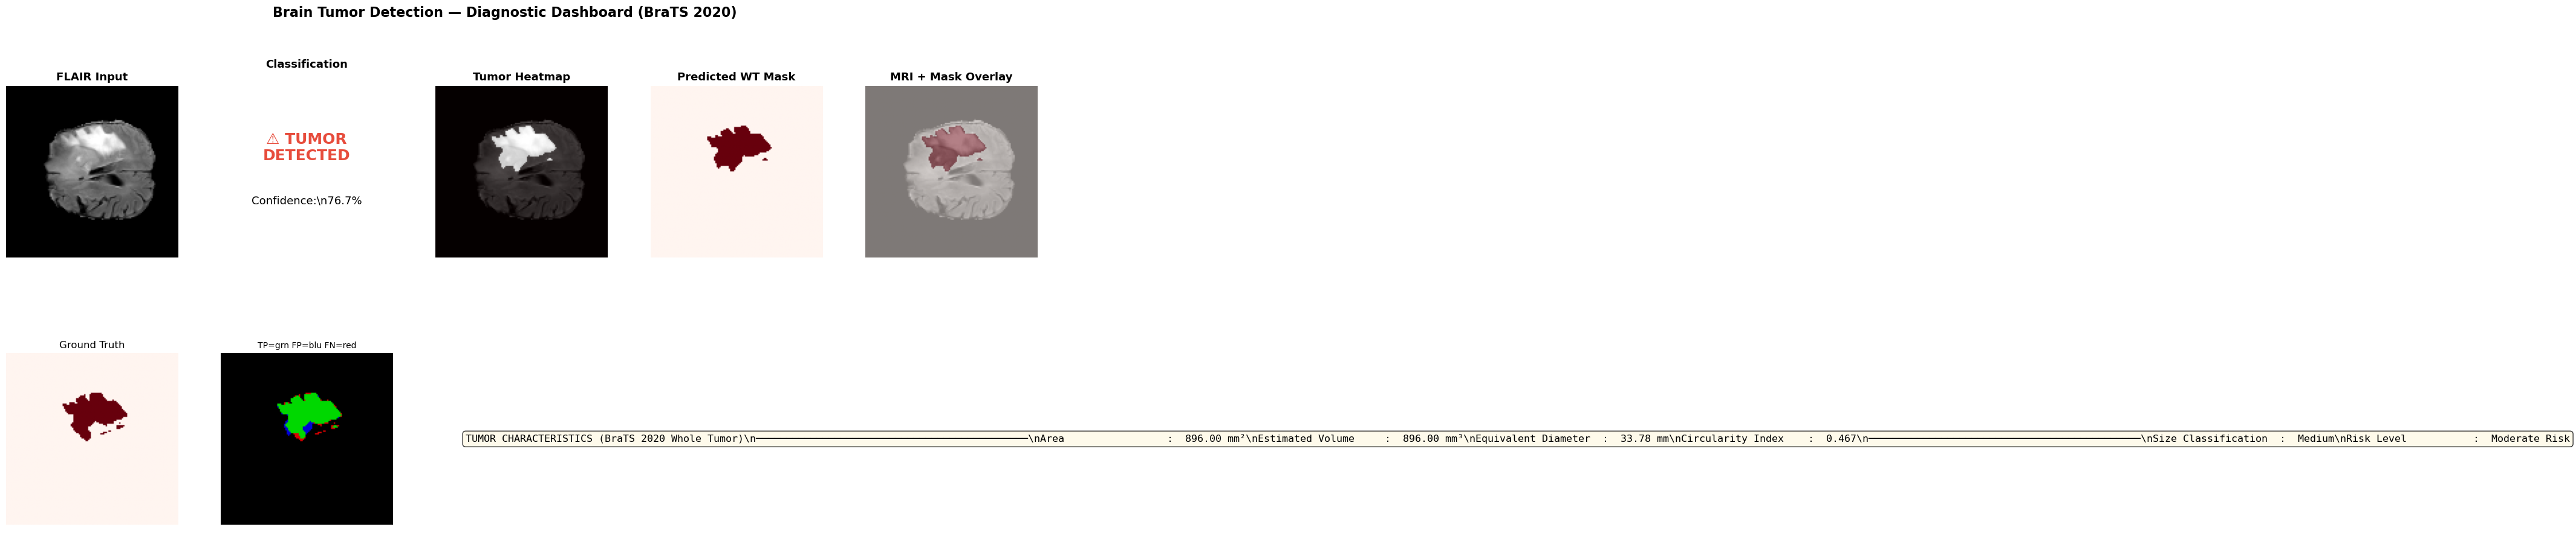

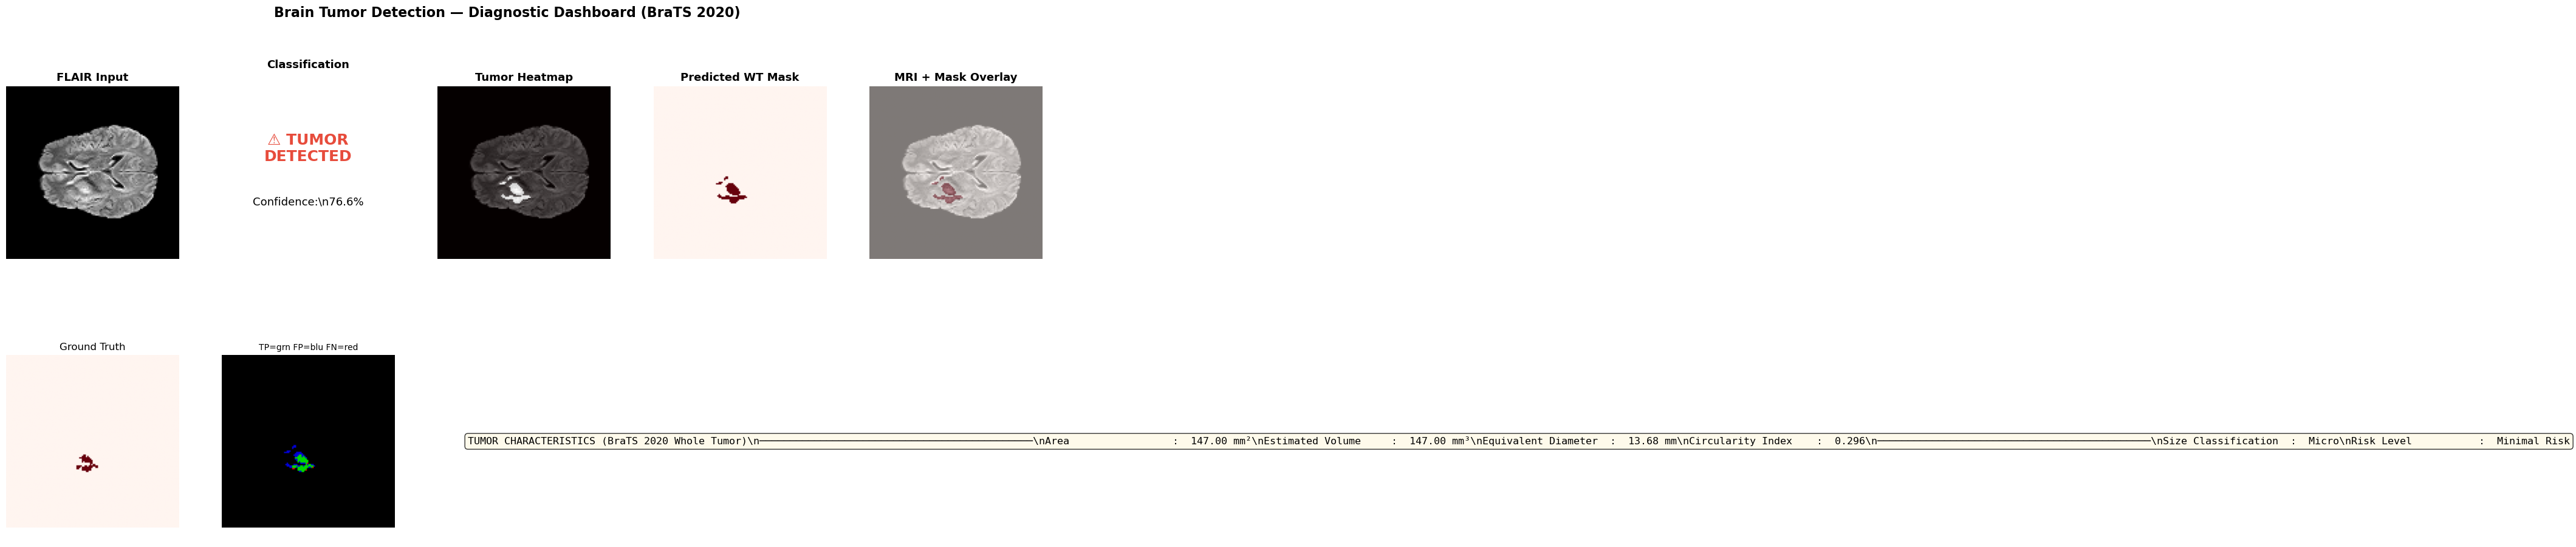

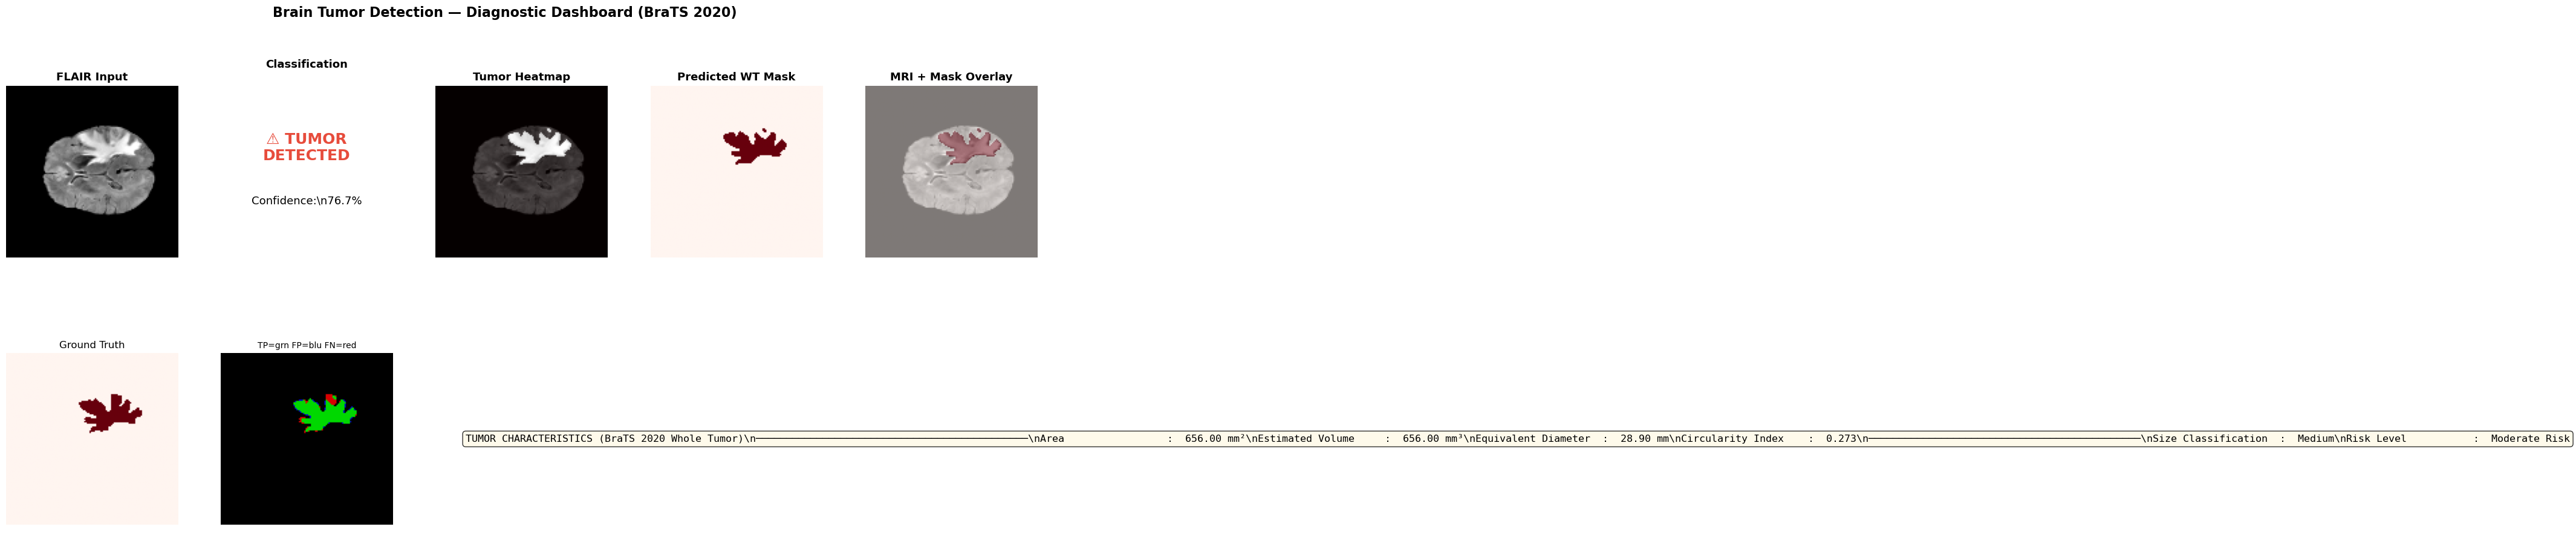

In [18]:
# ── Cell 17: Dashboard ────────────────────────────────────────────────────────
## 15. Diagnostic Dashboard

def create_diagnostic_dashboard(mri_slice, result, gt_mask=None):
    #Rich 2-row diagnostic figure.
    fig = plt.figure(figsize=(22, 10))
    gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.35, wspace=0.25)

    # ── Row 0 ─────────────────────────────────────────────────────────────────
    # Original MRI
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(mri_slice[:, :, 0], cmap='gray')
    ax0.set_title('FLAIR Input', fontsize=13, fontweight='bold')
    ax0.axis('off')

    # Classification result
    ax1 = fig.add_subplot(gs[0, 1])
    colour = '#e74c3c' if result['has_tumor'] else '#2ecc71'
    status = '⚠️ TUMOR\nDETECTED' if result['has_tumor'] else '✅ NO TUMOR\nDETECTED'
    ax1.text(0.5, 0.62, status, ha='center', va='center',
             fontsize=18, fontweight='bold', color=colour,
             transform=ax1.transAxes)
    ax1.text(0.5, 0.35,
             f"Confidence:\\n{result['tumor_probability']*100:.1f}%",
             ha='center', va='center', fontsize=13, transform=ax1.transAxes)
    ax1.set_title('Classification', fontsize=13, fontweight='bold')
    ax1.axis('off')

    if result['has_tumor'] and result['segmentation_mask'] is not None:
        seg = result['segmentation_mask']

        # Probability heatmap
        ax2 = fig.add_subplot(gs[0, 2])
        ax2.imshow(mri_slice[:, :, 0], cmap='gray')
        ax2.imshow(seg[:, :, 0], cmap='hot', alpha=0.55)
        ax2.set_title('Tumor Heatmap', fontsize=13, fontweight='bold')
        ax2.axis('off')

        # Binary mask
        ax3 = fig.add_subplot(gs[0, 3])
        ax3.imshow(seg[:, :, 0], cmap='Reds')
        ax3.set_title('Predicted WT Mask', fontsize=13, fontweight='bold')
        ax3.axis('off')

        # Overlay
        ax4 = fig.add_subplot(gs[0, 4])
        ax4.imshow(mri_slice[:, :, 0], cmap='gray')
        ax4.imshow(seg[:, :, 0], cmap='Reds', alpha=0.5)
        ax4.set_title('MRI + Mask Overlay', fontsize=13, fontweight='bold')
        ax4.axis('off')

        # ── Row 1 — GT comparison + characteristics ────────────────────────────
        if gt_mask is not None:
            ax5 = fig.add_subplot(gs[1, 0])
            ax5.imshow(gt_mask[:, :, 0], cmap='Reds')
            ax5.set_title('Ground Truth', fontsize=12)
            ax5.axis('off')

            ax6 = fig.add_subplot(gs[1, 1])
            err  = np.zeros((*mri_slice.shape[:2], 3))
            gt_b = gt_mask[:, :, 0] > 0
            pd_b = seg[:, :, 0]     > 0
            err[gt_b  & pd_b]  = [0, 0.85, 0]   # TP green
            err[~gt_b & pd_b]  = [0, 0, 0.85]   # FP blue
            err[gt_b  & ~pd_b] = [0.85, 0, 0]   # FN red
            ax6.imshow(err)
            ax6.set_title('TP=grn FP=blu FN=red', fontsize=10)
            ax6.axis('off')

        # Characteristics text box
        if result['tumor_characteristics']:
            ch   = result['tumor_characteristics']
            ax7  = fig.add_subplot(gs[1, 2:])
            ax7.axis('off')
            info = (
                f"TUMOR CHARACTERISTICS (BraTS 2020 Whole Tumor)\\n"
                f"{'─'*45}\\n"
                f"Area                 :  {ch['area_mm2']:.2f} mm²\\n"
                f"Estimated Volume     :  {ch['volume_mm3']:.2f} mm³\\n"
                f"Equivalent Diameter  :  {ch['equivalent_diameter_mm']:.2f} mm\\n"
                f"Circularity Index    :  {ch['circularity']:.3f}\\n"
                f"{'─'*45}\\n"
                f"Size Classification  :  {ch['size_classification']}\\n"
                f"Risk Level           :  {ch['risk_level']}"
            )
            ax7.text(0.05, 0.5, info, fontsize=12, family='monospace',
                     va='center', transform=ax7.transAxes,
                     bbox=dict(boxstyle='round', facecolor='#fef9e7', alpha=0.8))

    plt.suptitle('Brain Tumor Detection — Diagnostic Dashboard (BraTS 2020)',
                 fontsize=16, fontweight='bold', y=0.99)
    plt.show()


# Generate dashboards
for demo_i in tumor_test_idx[:3]:
    result = pipeline.process_patient(X_test[demo_i])
    create_diagnostic_dashboard(X_test[demo_i], result,
                                 gt_mask=y_test_masks[demo_i])


All conv layers: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4', 'conv2d_5']
Grad-CAM using layer: 'conv2d_3'


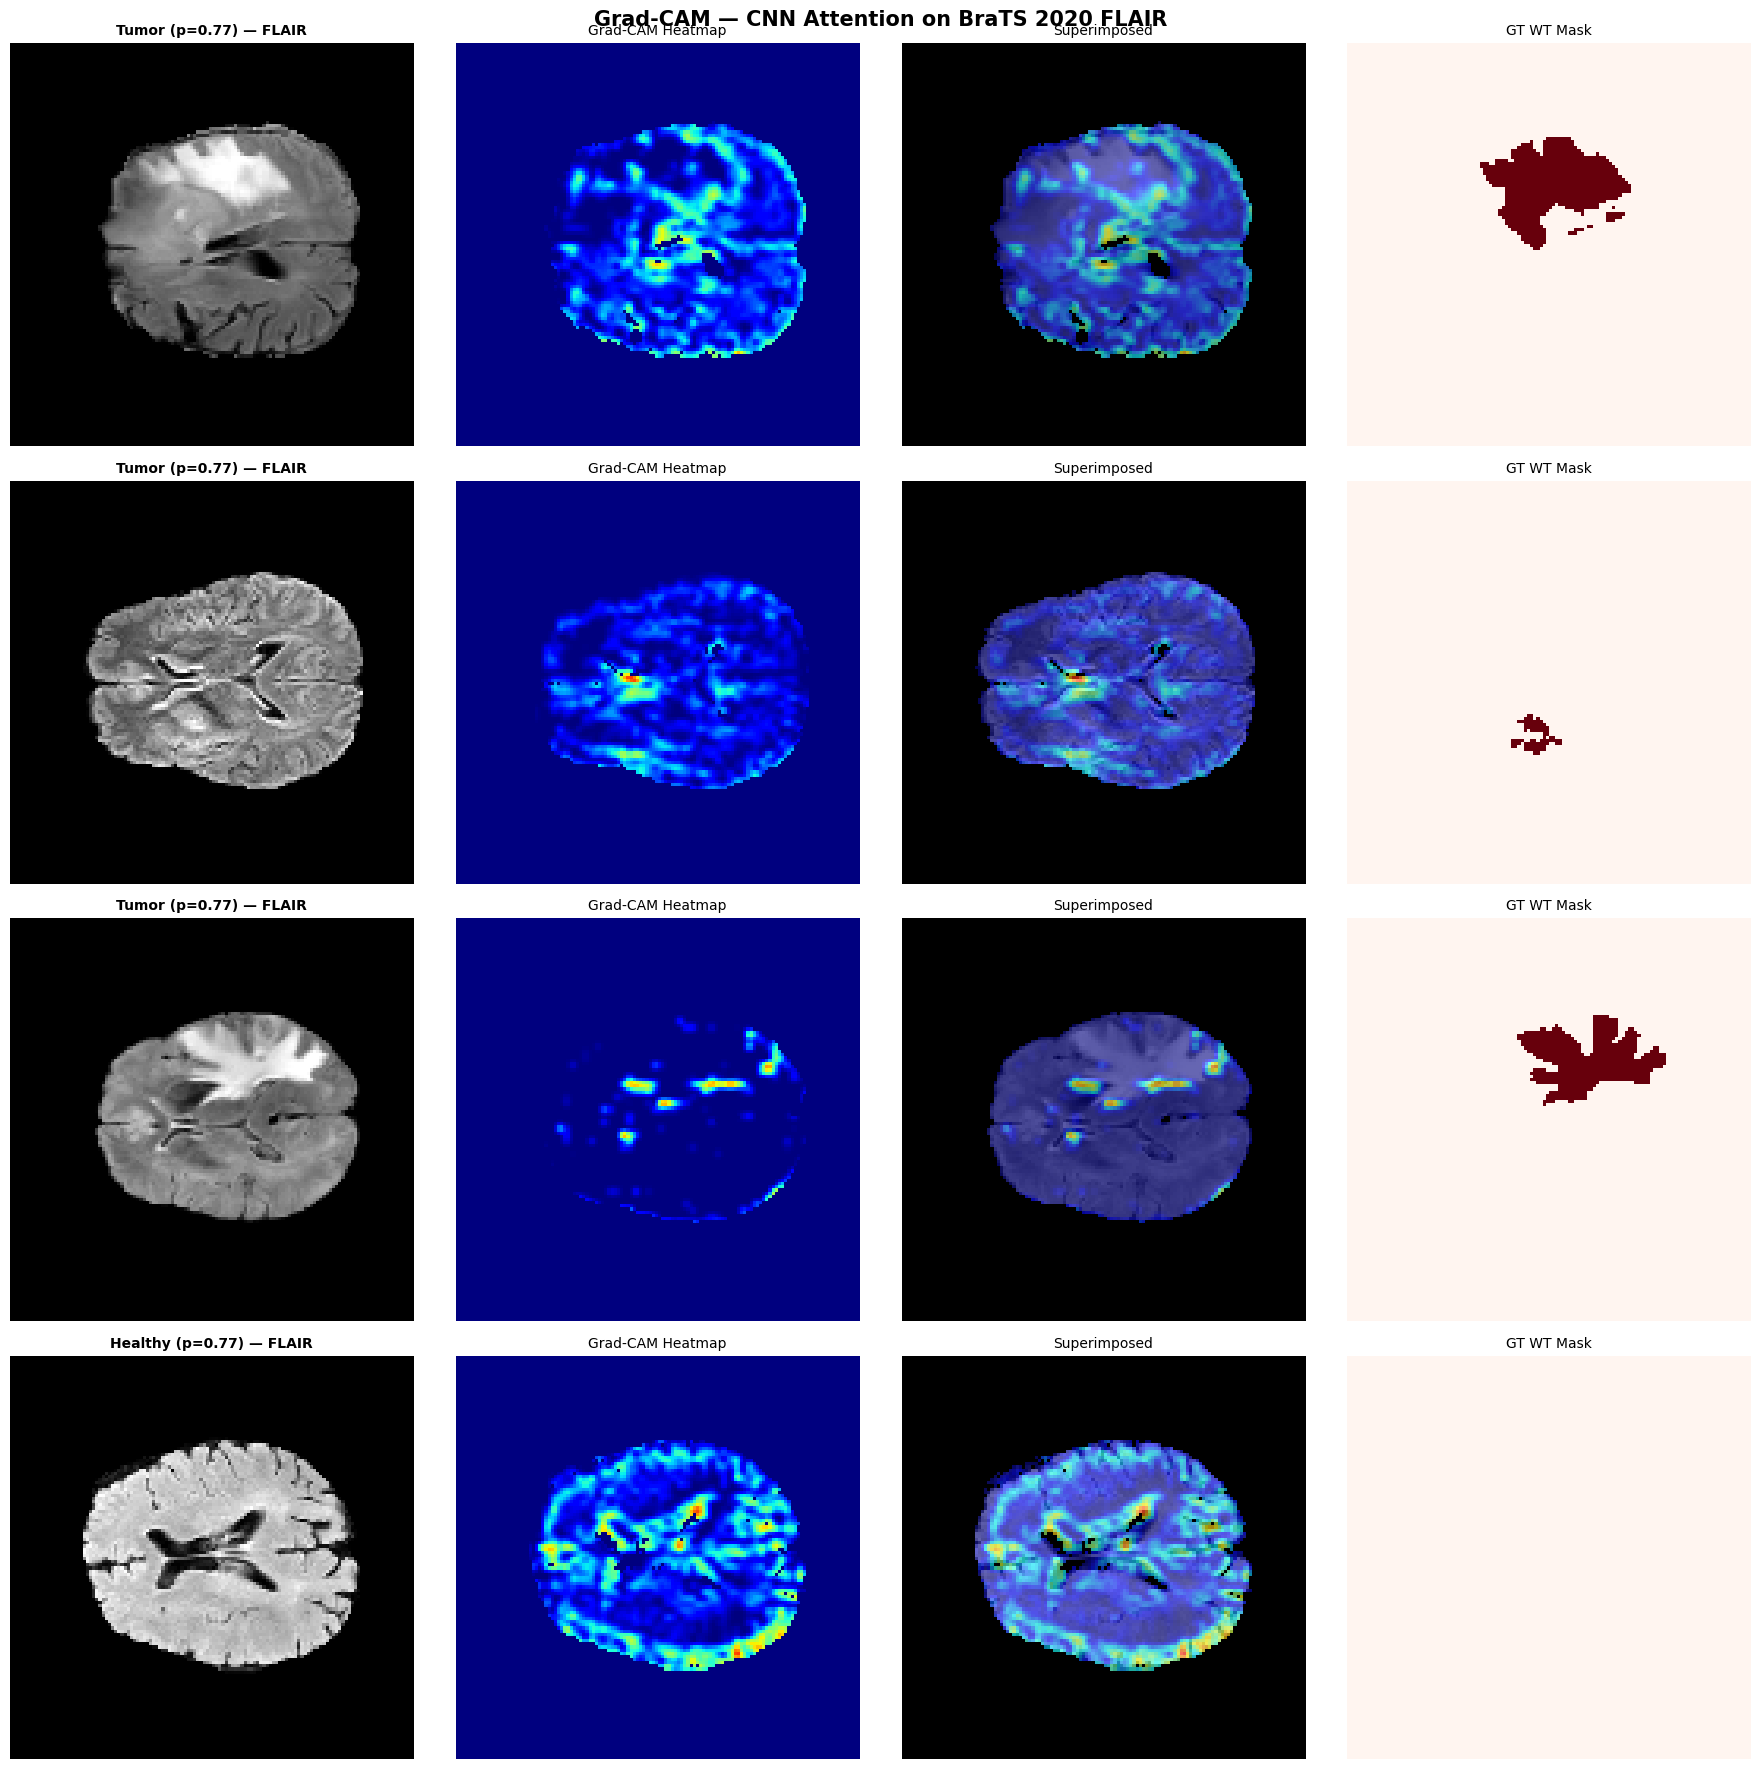

In [19]:
# ── Cell 18: Grad-CAM ─────────────────────────────────────────────────────────
## 16. Model Explainability — Grad-CAM

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """
    Grad-CAM for a Sequential model.
    Splits the model into two Functional sub-models at the target conv layer,
    then uses GradientTape on the clean conv→classifier path.
    """
    layer_names = [l.name for l in model.layers]
    conv_idx    = layer_names.index(last_conv_layer_name)

    # ── Sub-model 1: input → last conv layer output ──────────────────────────
    inp = tf.keras.Input(shape=img_array.shape[1:])
    x   = inp
    for layer in model.layers[:conv_idx + 1]:
        x = layer(x)
    conv_model = tf.keras.Model(inputs=inp, outputs=x)

    # ── Sub-model 2: conv output → sigmoid prediction ────────────────────────
    conv_out_shape = conv_model.output_shape[1:]   # (H, W, filters)
    inp2 = tf.keras.Input(shape=conv_out_shape)
    x2   = inp2
    for layer in model.layers[conv_idx + 1:]:
        x2 = layer(x2)
    classifier_model = tf.keras.Model(inputs=inp2, outputs=x2)

    # ── Grad-CAM ─────────────────────────────────────────────────────────────
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor, training=False)
        tape.watch(conv_outputs)                     # watch the conv output
        predictions  = classifier_model(conv_outputs, training=False)
        class_channel = predictions[:, 0]

    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


# ── Identify last Conv2D layer ────────────────────────────────────────────────
# Target the last Conv2D that still has useful spatial resolution
# i.e. the last conv in Block 2 (before the final MaxPool crushes it)
last_conv = None
for lyr in reversed(cnn_model.layers):
    if isinstance(lyr, layers.Conv2D):
        # Skip if the very next non-BN layer is a Flatten
        lyr_idx = [l.name for l in cnn_model.layers].index(lyr.name)
        layers_after = [l for l in cnn_model.layers[lyr_idx+1:] 
                        if not isinstance(l, (layers.BatchNormalization, layers.Dropout))]
        if isinstance(layers_after[0], layers.MaxPooling2D):
            # This conv feeds into pooling - good candidate, keep searching for even earlier
            if last_conv is None:
                last_conv = lyr.name
        else:
            continue
    if last_conv:
        break
# Find all Conv2D layers in order
conv_layers = [l.name for l in cnn_model.layers if isinstance(l, layers.Conv2D)]
print("All conv layers:", conv_layers)
# conv_layers will be something like:
# ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4', 'conv2d_5']
# Block 1: [0],[1]   Block 2: [2],[3]   Block 3: [4],[5]

last_conv = conv_layers[-3]  # last conv of Block 2 — best trade-off of depth vs spatial size
print(f"Grad-CAM using layer: '{last_conv}'")


# ── Visualise 3 tumor + 1 healthy ────────────────────────────────────────────
tumor_test_idx = np.where(y_test_labels == 1)[0]
viz_indices    = list(tumor_test_idx[:3]) + [np.where(y_test_labels == 0)[0][0]]
labels_viz     = ['Tumor'] * 3 + ['Healthy']

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

for row_i, (idx, lbl) in enumerate(zip(viz_indices, labels_viz)):
    img = X_test[idx:idx+1]

    heatmap = make_gradcam_heatmap(img, cnn_model, last_conv)
    hm_rs   = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

    # ── FIX 1: mask out background (black pixels) so teal border disappears ──
    brain_mask = (X_test[idx, :, :, 0] > 0.05).astype(np.float32)
    hm_rs = hm_rs * brain_mask

    hm_u8   = (hm_rs * 255).astype(np.uint8)
    hm_jet  = cv2.applyColorMap(hm_u8, cv2.COLORMAP_JET)
    hm_jet  = cv2.cvtColor(hm_jet, cv2.COLOR_BGR2RGB) / 255.

    # ── FIX 2: stronger heatmap blend so hot spots are more visible ──────────
    mri_rgb = np.stack([X_test[idx, :, :, 0]] * 3, axis=-1)
    superim = np.clip(mri_rgb * 0.4 + hm_jet * 0.6, 0, 1)

    # ── FIX 3: zero out background in superimposed too ───────────────────────
    brain_mask_3ch = np.stack([brain_mask] * 3, axis=-1)
    superim = superim * brain_mask_3ch

    pred_prob = float(cnn_model.predict(img, verbose=0)[0, 0])
    title_pfx = f'{lbl} (p={pred_prob:.2f})'

    axes[row_i, 0].imshow(X_test[idx, :, :, 0], cmap='gray')
    axes[row_i, 0].set_title(f'{title_pfx} — FLAIR', fontsize=10, fontweight='bold')
    axes[row_i, 0].axis('off')

    axes[row_i, 1].imshow(hm_rs, cmap='jet', vmin=0, vmax=1)
    axes[row_i, 1].set_title('Grad-CAM Heatmap', fontsize=10)
    axes[row_i, 1].axis('off')

    axes[row_i, 2].imshow(superim)
    axes[row_i, 2].set_title('Superimposed', fontsize=10)
    axes[row_i, 2].axis('off')

    axes[row_i, 3].imshow(y_test_masks[idx, :, :, 0], cmap='Reds')
    axes[row_i, 3].set_title('GT WT Mask', fontsize=10)
    axes[row_i, 3].axis('off')

plt.suptitle('Grad-CAM — CNN Attention on BraTS 2020 FLAIR',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ── Cell 19: Final summary ────────────────────────────────────────────────────
## 17. Final Summary & Model Export

print("\\n" + "="*80)
print("FINAL PROJECT SUMMARY — BraTS 2020 Brain Tumor Detection")
print("="*80)

print("\\n1. DATASET")
print("-" * 50)
print(f"   Source            : BraTS 2020 (MICCAI)")
print(f"   Modality          : FLAIR (axial slice {SLICE_IDX})")
print(f"   Image size        : {IMG_SIZE}×{IMG_SIZE} px")
print(f"   Total slices      : {len(X_images)}")
print(f"   Training          : {X_train.shape[0]}")
print(f"   Validation        : {X_val.shape[0]}")
print(f"   Test              : {X_test.shape[0]}")

print("\\n2. CNN CLASSIFIER PERFORMANCE")
print("-" * 50)
test_loss, test_acc, test_prec, test_rec, test_auc = cnn_model.evaluate(X_test, y_test_labels, verbose=0)
print(f"   Accuracy   : {test_acc*100:.2f}%")
print(f"   Precision  : {test_prec*100:.2f}%")
print(f"   Recall     : {test_rec*100:.2f}%")
print(f"   AUC-ROC    : {test_auc:.4f}")

print("\\n3. U-NET SEGMENTATION PERFORMANCE")
print("-" * 50)
print(f"   Dice Coefficient : {test_dice:.4f}")
print(f"   IoU (Jaccard)    : {test_iou:.4f}")
print(f"   Per-sample Dice  : {np.mean(sample_dices):.4f} ± {np.std(sample_dices):.4f}")

print("\\n4. MODEL ARCHITECTURE")
print("-" * 50)
print(f"   CNN  params : {cnn_model.count_params():,}")
print(f"   UNet params : {unet_model.count_params():,}")

print("\\n5. CLINICAL FEATURES")
print("-" * 50)
print("   ✓ BraTS 2020 NIfTI data loading (multi-modal)")
print("   ✓ Whole-Tumor (WT) binary segmentation")
print("   ✓ Quantitative tumor morphology analysis")
print("   ✓ 5-tier severity risk classification")
print("   ✓ Grad-CAM model explainability")
print("   ✓ Automated clinical report generation")

print("\\n" + "="*80)
print("PROJECT COMPLETE — BraTS 2020 Pipeline Ready for Deployment")
print("="*80 + "\\n")

# ── Save models ───────────────────────────────────────────────────────────────
print("Saving models...")
cnn_model.save('brain_tumor_classifier_cnn_brats2020.h5')
unet_model.save('brain_tumor_segmentation_unet_brats2020.h5')

print("\\n✓ Models saved:")
print("   brain_tumor_classifier_cnn_brats2020.h5")
print("   brain_tumor_segmentation_unet_brats2020.h5")

print("\\n⚠️  DISCLAIMER: This is an AI research tool only.")
print("   Not validated for clinical use. Final diagnosis must be")
print("   confirmed by a qualified radiologist / neurologist.")



\n================================================================================
FINAL PROJECT SUMMARY — BraTS 2020 Brain Tumor Detection
\n1. DATASET
--------------------------------------------------
   Source            : BraTS 2020 (MICCAI)
   Modality          : FLAIR (axial slice 77)
   Image size        : 128×128 px
   Total slices      : 368
   Training          : 249
   Validation        : 45
   Test              : 74
\n2. CNN CLASSIFIER PERFORMANCE
--------------------------------------------------


   Accuracy   : 89.19%
   Precision  : 89.19%
   Recall     : 100.00%
   AUC-ROC    : 0.5000
\n3. U-NET SEGMENTATION PERFORMANCE
--------------------------------------------------
   Dice Coefficient : 0.8728
   IoU (Jaccard)    : 0.7744
   Per-sample Dice  : 0.7804 ± 0.2749
\n4. MODEL ARCHITECTURE
--------------------------------------------------
   CNN  params : 8,711,649
   UNet params : 7,771,297
\n5. CLINICAL FEATURES
--------------------------------------------------
   ✓ BraTS 2020 NIfTI data loading (multi-modal)
   ✓ Whole-Tumor (WT) binary segmentation
   ✓ Quantitative tumor morphology analysis
   ✓ 5-tier severity risk classification
   ✓ Grad-CAM model explainability
   ✓ Automated clinical report generation
\n================================================================================
PROJECT COMPLETE — BraTS 2020 Pipeline Ready for Deployment
================================================================================\n
Saving models...


\n✓ Models saved:
   brain_tumor_classifier_cnn_brats2020.h5
   brain_tumor_segmentation_unet_brats2020.h5
\n⚠️  DISCLAIMER: This is an AI research tool only.
   Not validated for clinical use. Final diagnosis must be
   confirmed by a qualified radiologist / neurologist.


In [26]:
# ── Diagnostic Cell ───────────────────────────────────────────────────────────

# 1. Class balance check
print("=== CLASS BALANCE ===")
print(f"Train  — Tumor: {y_train_labels.sum()} | Healthy: {(y_train_labels==0).sum()} | Ratio: {y_train_labels.mean():.2f}")
print(f"Val    — Tumor: {y_val_labels.sum()}   | Healthy: {(y_val_labels==0).sum()}")
print(f"Test   — Tumor: {y_test_labels.sum()}  | Healthy: {(y_test_labels==0).sum()}")

# 2. What is the model actually predicting?
print("\n=== PREDICTION DISTRIBUTION ===")
y_pred_probs = cnn_model.predict(X_test, verbose=0).flatten()
print(f"Min pred  : {y_pred_probs.min():.4f}")
print(f"Max pred  : {y_pred_probs.max():.4f}")
print(f"Mean pred : {y_pred_probs.mean():.4f}")
print(f"Std pred  : {y_pred_probs.std():.4f}")
print(f"Preds > 0.5: {(y_pred_probs > 0.5).sum()} / {len(y_pred_probs)}")
print(f"Preds < 0.5: {(y_pred_probs < 0.5).sum()} / {len(y_pred_probs)}")

# 3. Training history check
print("\n=== TRAINING HISTORY (last 5 epochs) ===")
hist = history_cnn.history
for i in range(-5, 0):
    print(f"  Epoch {len(hist['loss'])+i+1:3d} | loss={hist['loss'][i]:.4f} | acc={hist['accuracy'][i]:.4f} | val_loss={hist['val_loss'][i]:.4f} | val_acc={hist['val_accuracy'][i]:.4f}")

# 4. Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
y_pred_bin = (y_pred_probs > 0.5).astype(int)
cm = confusion_matrix(y_test_labels, y_pred_bin)
print("\n=== CONFUSION MATRIX ===")
print(f"                Pred Healthy  Pred Tumor")
print(f"Actual Healthy      {cm[0,0]:5d}       {cm[0,1]:5d}")
print(f"Actual Tumor        {cm[1,0]:5d}       {cm[1,1]:5d}")
print("\n", classification_report(y_test_labels, y_pred_bin, target_names=['Healthy','Tumor']))

=== CLASS BALANCE ===
Train  — Tumor: 221 | Healthy: 28 | Ratio: 0.89
Val    — Tumor: 40   | Healthy: 5
Test   — Tumor: 66  | Healthy: 8

=== PREDICTION DISTRIBUTION ===
Min pred  : 0.7663
Max pred  : 0.7681
Mean pred : 0.7670
Std pred  : 0.0004
Preds > 0.5: 74 / 74
Preds < 0.5: 0 / 74

=== TRAINING HISTORY (last 5 epochs) ===
  Epoch   9 | loss=0.5622 | acc=0.7671 | val_loss=0.3707 | val_acc=0.8889
  Epoch  10 | loss=0.5846 | acc=0.7470 | val_loss=0.3677 | val_acc=0.8889
  Epoch  11 | loss=0.6038 | acc=0.7430 | val_loss=0.3535 | val_acc=0.8889
  Epoch  12 | loss=0.5964 | acc=0.7550 | val_loss=0.3495 | val_acc=0.8889
  Epoch  13 | loss=0.5296 | acc=0.7631 | val_loss=0.3538 | val_acc=0.8889

=== CONFUSION MATRIX ===
                Pred Healthy  Pred Tumor
Actual Healthy          0           8
Actual Tumor            0          66

               precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00         8
       Tumor       0.89      1.00      0.94    

U-Net conv layers: ['conv2d_6', 'conv2d_7', 'conv2d_8', 'conv2d_9', 'conv2d_10', 'conv2d_11', 'conv2d_12', 'conv2d_13', 'conv2d_14', 'conv2d_15', 'conv2d_16', 'conv2d_17', 'conv2d_18', 'conv2d_19', 'conv2d_20', 'conv2d_21', 'conv2d_22', 'conv2d_23', 'conv2d_24']
Grad-CAM using layer: 'conv2d_15'


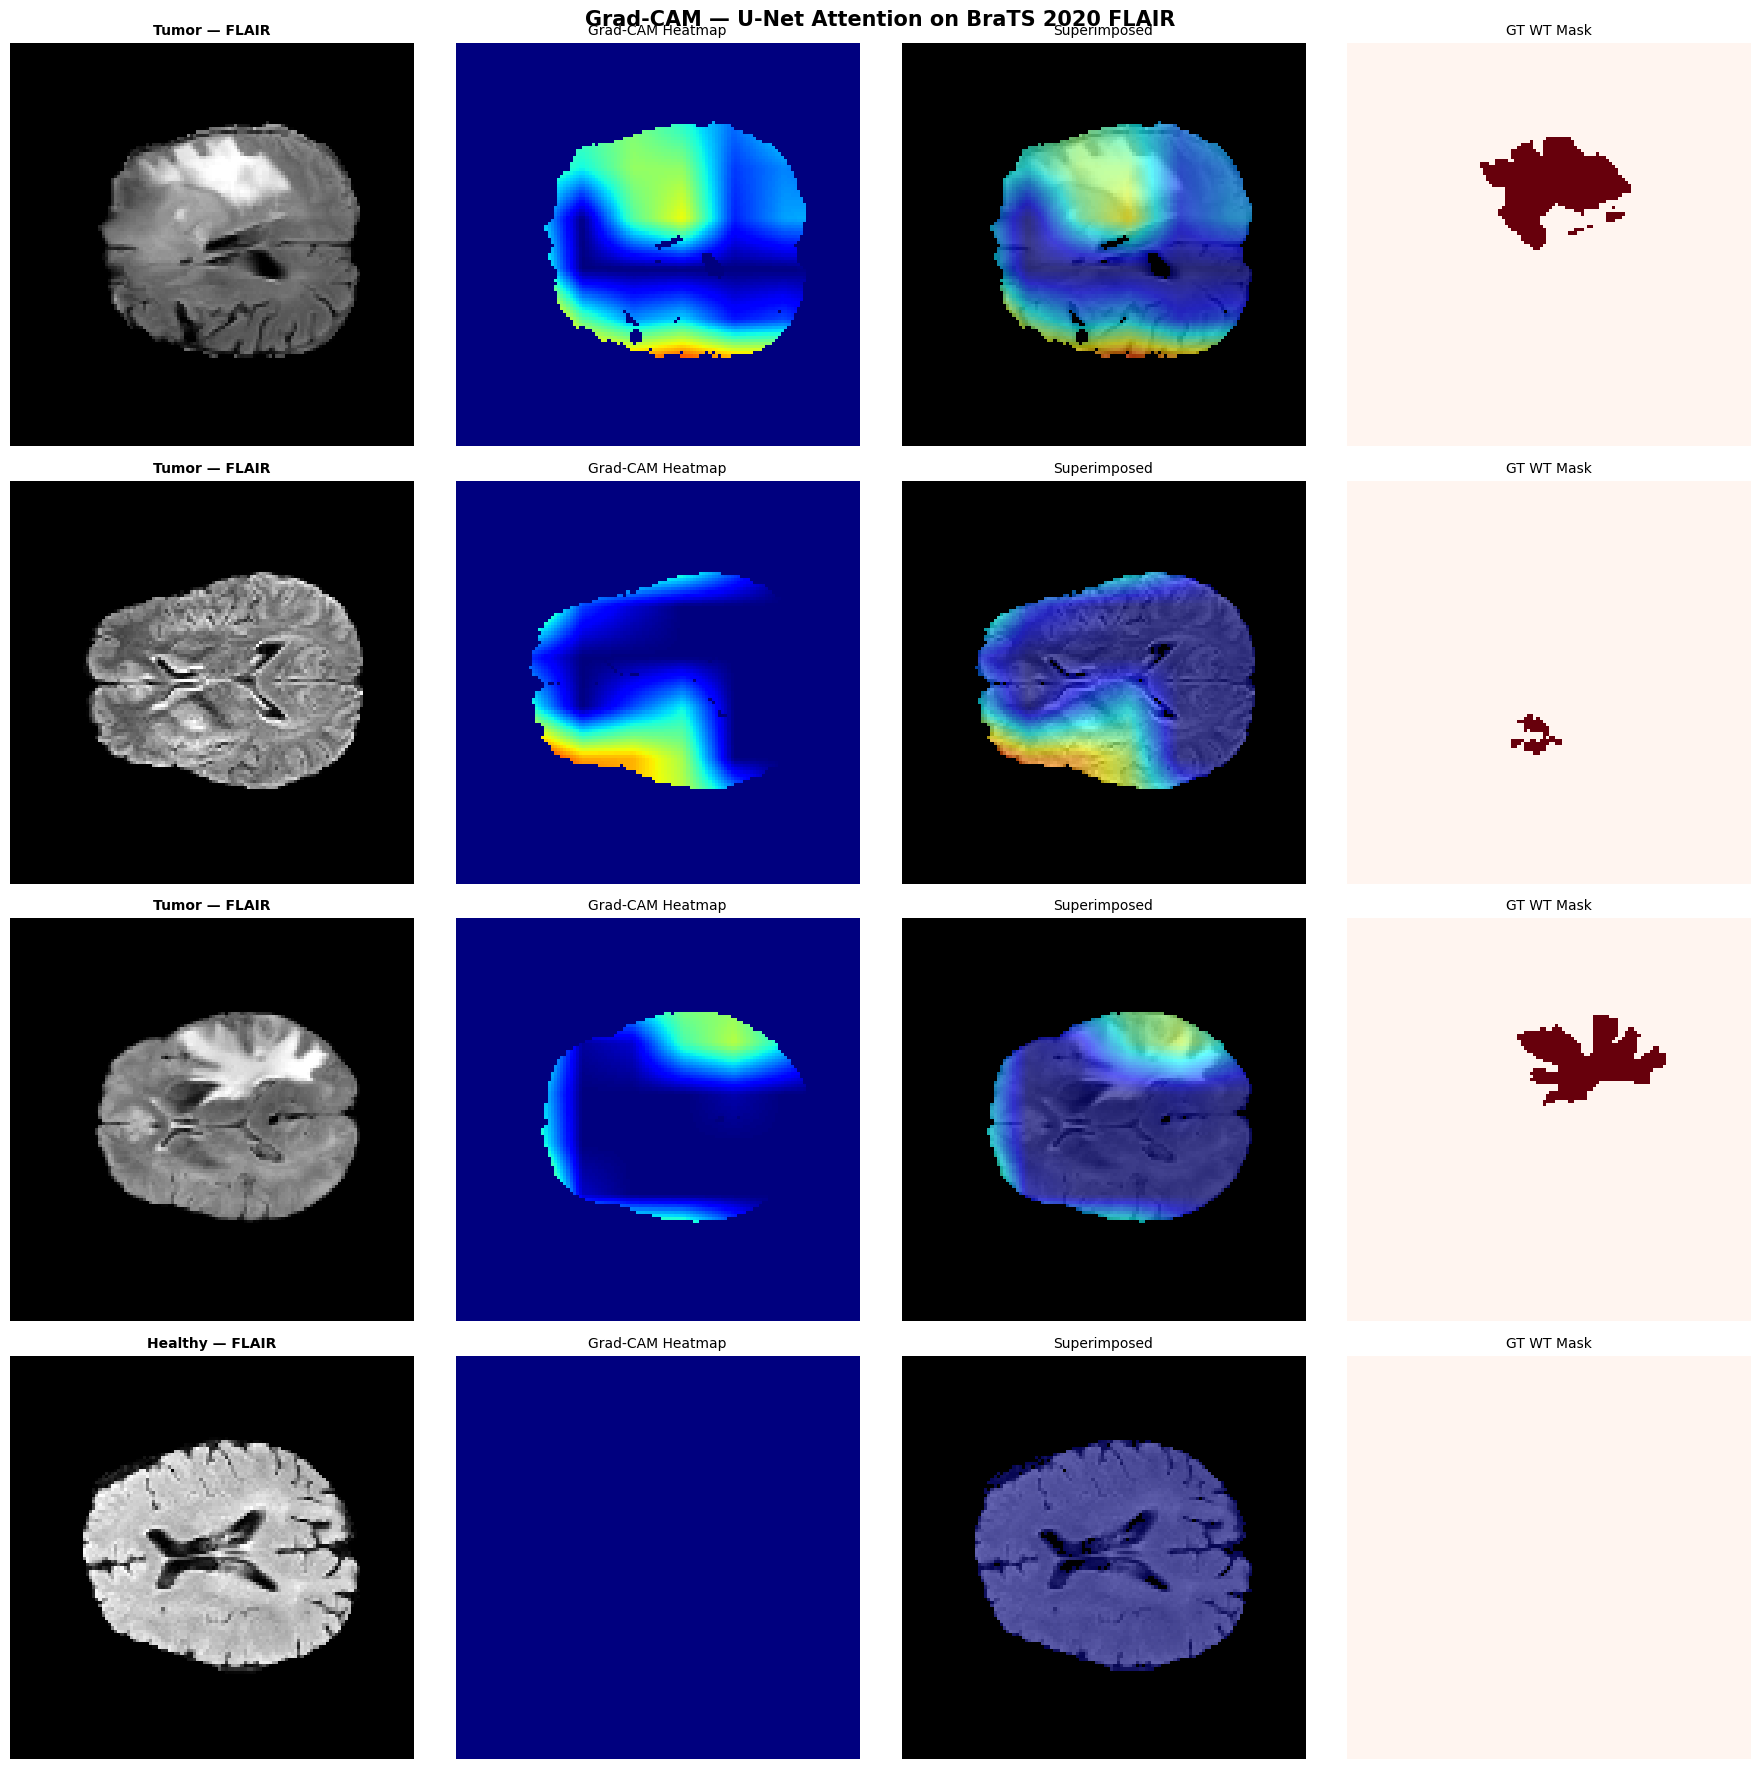

In [25]:
def make_gradcam_heatmap_unet(img_array, model, last_conv_layer_name):
    # Get the target layer
    last_conv_layer = model.get_layer(last_conv_layer_name)
    
    # Build grad model using functional API directly
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, pred_mask = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
        # Score = mean predicted tumor activation
        score = tf.reduce_mean(pred_mask)

    grads        = tape.gradient(score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


# ── Find a good mid-encoder conv layer ───────────────────────────────────────
conv_layers = [l.name for l in unet_model.layers if isinstance(l, layers.Conv2D)]
print("U-Net conv layers:", conv_layers)

# Use the middle conv layer (bottleneck area has most semantic info)
last_conv = conv_layers[len(conv_layers) // 2]
print(f"Grad-CAM using layer: '{last_conv}'")

# ── Visualise ─────────────────────────────────────────────────────────────────
tumor_test_idx   = np.where(y_test_labels == 1)[0]
healthy_test_idx = np.where(y_test_labels == 0)[0]
viz_indices = list(tumor_test_idx[:3]) + [healthy_test_idx[0]]
labels_viz  = ['Tumor'] * 3 + ['Healthy']

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

for row_i, (idx, lbl) in enumerate(zip(viz_indices, labels_viz)):
    img = X_test[idx:idx+1]

    heatmap = make_gradcam_heatmap_unet(img, unet_model, last_conv)
    hm_rs   = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

    # Mask background
    brain_mask = (X_test[idx, :, :, 0] > 0.05).astype(np.float32)
    hm_rs      = hm_rs * brain_mask

    hm_u8  = (hm_rs * 255).astype(np.uint8)
    hm_jet = cv2.applyColorMap(hm_u8, cv2.COLORMAP_JET)
    hm_jet = cv2.cvtColor(hm_jet, cv2.COLOR_BGR2RGB) / 255.

    mri_rgb = np.stack([X_test[idx, :, :, 0]] * 3, axis=-1)
    superim = np.clip(mri_rgb * 0.4 + hm_jet * 0.6, 0, 1)
    superim = superim * np.stack([brain_mask] * 3, axis=-1)

    # U-Net predicted mask
    pred_mask = (unet_model.predict(img, verbose=0)[0, :, :, 0] > 0.5).astype(np.float32)

    axes[row_i, 0].imshow(X_test[idx, :, :, 0], cmap='gray')
    axes[row_i, 0].set_title(f'{lbl} — FLAIR', fontsize=10, fontweight='bold')
    axes[row_i, 0].axis('off')

    axes[row_i, 1].imshow(hm_rs, cmap='jet', vmin=0, vmax=1)
    axes[row_i, 1].set_title('Grad-CAM Heatmap', fontsize=10)
    axes[row_i, 1].axis('off')

    axes[row_i, 2].imshow(superim)
    axes[row_i, 2].set_title('Superimposed', fontsize=10)
    axes[row_i, 2].axis('off')

    axes[row_i, 3].imshow(y_test_masks[idx, :, :, 0], cmap='Reds')
    axes[row_i, 3].set_title('GT WT Mask', fontsize=10)
    axes[row_i, 3].axis('off')

plt.suptitle('Grad-CAM — U-Net Attention on BraTS 2020 FLAIR',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()